In [1]:
# Waveform and Firing Rate Clustering Analysis
# This notebook performs comprehensive clustering analysis combining waveform data with firing rate and bursting metrics

import pynapple as nap
from spikeinterface import load_sorting_analyzer
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import fnmatch
import matplotlib as mpl
import re
import os
from scipy import stats
from sklearn.decomposition import PCA, FastICA
from scipy.linalg import norm
from scipy.stats import kstest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
from scipy.signal import correlate
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded successfully!")

# Bursting capacity metrics based on autocorrelograms
def calculate_autocorrelogram(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate autocorrelogram for spike times.
    
    Parameters:
    - spike_times: array of spike times in seconds
    - bin_size: bin size in seconds (default 1ms)
    - window_size: window size in seconds (default 100ms)
    
    Returns:
    - bins: time bins
    - autocorr: autocorrelogram values
    """
    if len(spike_times) < 2:
        return np.array([0]), np.array([0])
    
    # Create bins
    bins = np.arange(-window_size, window_size + bin_size, bin_size)
    
    # Calculate autocorrelogram
    autocorr = np.zeros(len(bins) - 1)
    
    for i, spike_time in enumerate(spike_times):
        # Find all other spikes
        other_spikes = np.concatenate([spike_times[:i], spike_times[i+1:]])
        
        # Calculate time differences
        time_diffs = other_spikes - spike_time
        
        # Bin the differences
        hist, _ = np.histogram(time_diffs, bins=bins)
        autocorr += hist
    
    # Normalize by number of spikes
    autocorr = autocorr / len(spike_times)
    
    return bins[:-1], autocorr

def calculate_bursting_metrics(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate multiple bursting capacity metrics from autocorrelogram.
    
    Returns a dictionary with various bursting metrics:
    1. Burst Index: ratio of short-interval spikes to long-interval spikes
    2. Refractory Period Violation: spikes in refractory period
    3. Burst Peak Height: height of the first peak after time 0
    4. Burst Peak Width: width of the first peak
    5. Autocorr Skewness: skewness of the autocorrelogram
    6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    """
    if len(spike_times) < 10:  # Need sufficient spikes for reliable metrics
        return {
            'burst_index': 0,
            'refractory_violation': 0,
            'burst_peak_height': 0,
            'burst_peak_width': 0,
            'autocorr_skewness': 0,
            'short_isi_ratio': 0,
            'autocorr_vector': np.zeros(200)  # Fixed size for consistency
        }
    
    # Calculate autocorrelogram
    bins, autocorr = calculate_autocorrelogram(spike_times, bin_size, window_size)
    
    # Find center bin (time = 0)
    center_idx = len(bins) // 2
    
    # 1. Burst Index: ratio of short-interval spikes (1-10ms) to long-interval spikes (50-100ms)
    short_window = (bins >= 0.001) & (bins <= 0.010)  # 1-10ms
    long_window = (bins >= 0.050) & (bins <= 0.100)   # 50-100ms
    
    short_count = np.sum(autocorr[short_window])
    long_count = np.sum(autocorr[long_window])
    burst_index = short_count / (long_count + 1e-10)  # Add small value to avoid division by zero
    
    # 2. Refractory Period Violation: spikes in 0-2ms window
    refractory_window = (bins >= 0) & (bins <= 0.002)
    refractory_violation = np.sum(autocorr[refractory_window])
    
    # 3. Burst Peak Height: height of the first peak after time 0
    # Look for peaks in the 1-20ms window
    peak_window = (bins >= 0.001) & (bins <= 0.020)
    if np.any(peak_window):
        burst_peak_height = np.max(autocorr[peak_window])
    else:
        burst_peak_height = 0
    
    # 4. Burst Peak Width: width at half height of the first peak
    if burst_peak_height > 0:
        half_height = burst_peak_height / 2
        # Fix the indexing issue - use the correct window for peak_indices
        peak_indices = np.where(autocorr[peak_window] >= half_height)[0]
        if len(peak_indices) > 0:
            burst_peak_width = (np.max(peak_indices) - np.min(peak_indices)) * bin_size
        else:
            burst_peak_width = 0
    else:
        burst_peak_width = 0
    
    # 5. Autocorr Skewness: skewness of the autocorrelogram
    autocorr_skewness = stats.skew(autocorr)
    
    # 6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    isis = np.diff(spike_times)
    short_isis = np.sum(isis < 0.010)
    total_isis = len(isis)
    short_isi_ratio = short_isis / (total_isis + 1e-10)
    
    # Create a standardized autocorr vector (fixed size for consistency)
    autocorr_vector = np.zeros(200)
    if len(autocorr) > 0:
        # Interpolate to fixed size
        autocorr_vector = np.interp(np.linspace(0, len(autocorr)-1, 200), 
                                  np.arange(len(autocorr)), autocorr)
    
    return {
        'burst_index': burst_index,
        'refractory_violation': refractory_violation,
        'burst_peak_height': burst_peak_height,
        'burst_peak_width': burst_peak_width,
        'autocorr_skewness': autocorr_skewness,
        'short_isi_ratio': short_isi_ratio,
        'autocorr_vector': autocorr_vector
    }

print("Bursting metrics functions defined")

def imec_key_sorter(key):
    """Extract the number after 'imec', default to a large number if not found."""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

Traceback (most recent call last):
  File "/userdata/gumbach/miniforge3/envs/my_se2nwb/lib/python3.10/site-packages/tensorflow/python/pywrap_tensorflow.py", line 27, in <module>
    import ssl
  File "/userdata/gumbach/miniforge3/envs/my_se2nwb/lib/python3.10/ssl.py", line 99, in <module>
    import _ssl             # if we can't import it, let the error propagate
ImportError: /lib/x86_64-linux-gnu/libcrypto.so.3: version `OPENSSL_3.3.0' not found (required by /userdata/gumbach/miniforge3/envs/my_se2nwb/lib/python3.10/lib-dynload/_ssl.cpython-310-x86_64-linux-gnu.so)




2026-04-21 08:33:50.261652: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All imports loaded successfully!
Bursting metrics functions defined


In [2]:
# subject code for epilepsy cohort
# not including 53 right now, consider for FLAIR+ only control
nwb_paths = [
    Path("/data_store2/neuropixels/nwb/NP59_B1/NP59_B1.nwb"), # aSTG
    Path("/data_store2/neuropixels/nwb/NP59_B2/NP59_B2.nwb"), # aSTG
    Path("/data_store2/neuropixels/nwb/NP67_B1/NP67_B1.nwb"), # aSTG
    Path("/data_store2/neuropixels/nwb/NP76_B1/NP76_B1.nwb"), # pSTG
    Path("/data_store2/neuropixels/nwb/NP77_B2/NP77_B2.nwb"), # smg 
    Path("/data_store2/neuropixels/nwb/NP148_B2/NP148_B2.nwb"), # sfg
    ]   

### adjust for the depth of the probe
subj_list = [1, 2, 3, 4, 5, 6]
path_list = ['???', '???', '???', '???', '???', '???']
grade_list = [2, 2, 2, 2, 2, 2]
opercular_list = [0, 0, 0, 0, 0, 0]
yield_list = [28, 32, 27, 87, 74, 30]
region_list = ['aSTG','aSTG','aSTG','pSTG','SMG','SFG']
age_list = [32, 32, 46, 39, 22, 47]
gender_list = [0, 0, 0, 1, 0, 1]

manual_exclude_lists = [
    [90, 172, 247, 460, 478, 572, 600], # NP59_B1.imec0
    [6, 25, 38, 41, 49, 54, 61, 62, 65, 70, 76, 77, 83, 90, 96, 97, 111, 119, 121, 126, 128, 133, 148, 152, 170], # NP59_B2.imec0
    [11, 32, 51, 67, 75, 79, 82, 98, 125, 215, 236, 242, 244, 258, 259, 274, 275, 278, 281, 284, 294, 298, 303, 305, 309, 320, 327, 344, 346, 360, 361, 365, 371, 378, 381, 385, 409, 420, 426, 434, 440, 441, 444, 474, 480, 546, 547, 558, 595, 601, 604, 640, 654, 662, 668, 670, 681, 682, 693, 694, 695, 701, 707, 708, 709, 715, 716, 717, 719, 720, 721, 722, 735, 740], # NP67_B1.imec0
    [62, 64, 95, 119, 128, 191, 203, 207, 224, 228, 250, 269, 361, 427, 444, 479, 502, 510, 512, 529, 563], # NP76_B1.imec0
    [41, 190, 206], # NP77_B2.imec0
    [73, 94, 114, 131, 148, 162, 165, 209, 296], # NP148_B2.imec0
]

tipDepth_list = [
    6171, # NP59_B1.imec0
    6960, # NP59_B2.imec0
    7344, # NP67_B1.imec0
    6938, # NP76_B1.imec0
    7640, # NP77_B2.imec0
    7500, # NP148_B2.imec0
]

print(f"Loaded {len(nwb_paths)} NWB files for epilepsy control")
print(len(subj_list))
print(len(path_list))
print(len(yield_list))
print(len(region_list))
print(len(age_list))
print(len(gender_list))
print(len(manual_exclude_lists))
print(len(tipDepth_list))


Loaded 6 NWB files for epilepsy control
6
6
6
6
6
6
6
6


In [4]:
# MAIN LOOP TO EXTRACT WAVEFORMS, FIRING RATES, AND COMPREHENSIVE METRICS
# If summed behavioral duration > 10 min: restrict to beh epochs (unchanged logic).
# If < 10 min: use full recording (no restrict); KS uses recording time span.

print("Starting data extraction from all sessions...")

MIN_BEHAVIOR_MINUTES = 10.0

def _behavior_duration_seconds(task_times_obj):
    starts = np.asarray(task_times_obj.start, dtype=float).ravel()
    ends = np.asarray(task_times_obj.end, dtype=float).ravel()
    if starts.size != ends.size:
        return np.nan
    return float(np.sum(ends - starts))

def _ks_time_bounds_full_recording(spike_times_obj):
    """Min/max time for uniform KS (full recording)."""
    # span of all units' spike times
    tmin, tmax = np.inf, -np.inf
    for u in range(len(spike_times_obj)):
        idx = spike_times_obj[u].as_series().index.values
        if len(idx):
            tmin = min(tmin, float(np.min(idx)))
            tmax = max(tmax, float(np.max(idx)))
    if np.isfinite(tmin) and np.isfinite(tmax):
        return tmin, tmax
    return np.nan, np.nan

# Initialize data storage lists
indicesAll = []
firingRatesAll = []
waveformAll = []
depthAll = []
burstingMetricsAll = []
autocorrVectorsAll = []
spikeTimesAll = []

insertion = 0

for i in range(len(nwb_paths)):
    print(f"\nProcessing session {i+1}/{len(nwb_paths)}: {nwb_paths[i].name}")

    try:
        data = nap.load_file(nwb_paths[i])
        keys = data.keys()

        template = "*imec*"
        keys = [key for key in keys if fnmatch.fnmatch(key, template)]
        ks_keys = [key for key in keys if "KS4" in key]
        if ks_keys:
            keys = ks_keys
        th8_keys = [key for key in keys if "Th=8" in key]
        if th8_keys:
            keys = th8_keys
        else:
            th_keys = [key for key in keys if "Th=" in key]
            if th_keys:
                keys = th_keys
        template_sentgen = "*sentgen*"
        template_auto = "*_auto*"
        keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
        if ("NP137" in str(nwb_paths[i])) or ("NP139_B2" in str(nwb_paths[i])):
            keys = [key for key in keys if "imec1" not in key]
        keys = sorted(keys, key=imec_key_sorter)

        for s in range(len(keys)):
            print(f"Processing {keys[s]}")

            spike_times = data[keys[s]]
            firingRates_all = spike_times.metadata["rate"]

            if "TaskTimes" in data.keys():
                task_times = data["TaskTimes"]
            else:
                task_times = data["task_times"]

            start_time = task_times.start
            end_time = task_times.end
            beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)

            beh_sec = _behavior_duration_seconds(task_times)
            beh_min = beh_sec / 60.0 if np.isfinite(beh_sec) else np.nan
            use_full_recording = (not np.isfinite(beh_min)) or (beh_min < MIN_BEHAVIOR_MINUTES)

            if use_full_recording:
                spike_times_beh = spike_times
                firingRates_beh = firingRates_all
                min_time, max_time = _ks_time_bounds_full_recording(spike_times)
                if not (np.isfinite(min_time) and np.isfinite(max_time)) or (max_time <= min_time):
                    print(f"  Short behavior ({beh_min:.2f} min) but could not get recording bounds; skipping shank")
                    continue
                print(
                    f"  Behavioral duration {beh_min:.2f} min (< {MIN_BEHAVIOR_MINUTES} min) — using full recording for filters; KS window [{min_time:.3f}, {max_time:.3f}] s"
                )
            else:
                spike_times_beh = spike_times.restrict(beh_epochs)
                firingRates_beh = spike_times_beh.metadata["rate"]
                min_time = start_time[0]
                max_time = end_time[-1]
                print(
                    f"  Behavioral duration {beh_min:.2f} min (>= {MIN_BEHAVIOR_MINUTES} min) — using TaskTimes restrict; KS window [{min_time:.3f}, {max_time:.3f}] s"
                )

            # Quality checks (KS test, violation percentage)
            ks_stats = np.zeros(len(spike_times))
            ks_pvals = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                test = spike_times[u].as_series().index.values
                if len(test) > 1:
                    normalized_spike_times = (test - min_time) / (max_time - min_time)
                    ks_result = kstest(normalized_spike_times, "uniform")
                    ks_stats[u] = ks_result.statistic
                    ks_pvals[u] = ks_result.pvalue
                else:
                    ks_stats[u] = np.nan
                    ks_pvals[u] = np.nan

            violationThreshold = 3 / 1000
            violationPct = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                unit = spike_times[u]
                unit = unit.as_series().index
                if len(unit) < 100:
                    violationPct[u] = 1
                else:
                    isi = unit.diff()[1:]
                    violations = np.where(isi < violationThreshold)
                    violations = np.array(violations)
                    violationPct[u] = violations.size / len(isi)

            if "KSLabel" in spike_times.metadata:
                KSLabels = spike_times.metadata["KSLabel"]
            else:
                KSLabels = spike_times.metadata["quality"]

            firingRates = firingRates_beh
            mask1 = violationPct < 3 / 100
            mask2 = firingRates > 0.5
            mask3 = KSLabels != "noise"
            mask4 = ks_stats < 0.3
            mask = mask1 & mask2 & mask3 & mask4
            indicesFinal = firingRates.index[mask]

            indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion])
            insertion += 1
            spike_times_good = spike_times[indicesFinal]
            print(f"Number of good neurons: {len(spike_times_good)}")

            if len(spike_times_good) == 0:
                print("No good neurons found, skipping session")
                continue

            kilosort_run = f"{keys[s]}_sparse"
            rec_id = os.path.basename(nwb_paths[i])
            rec_id = os.path.splitext(rec_id)[0]
            # If kilosort_run starts with 'catgt_', remove the prefix
            if kilosort_run.startswith("catgt_"):
                kilosort_run = kilosort_run[len("catgt_"):]
   
            analyzer_path = f"/data_store2/neuropixels/nwb/{rec_id}/SI/{kilosort_run}"
            
            if not os.path.exists(analyzer_path):
                print(f"Analyzer path not found: {analyzer_path}")
                continue

            analyzer = load_sorting_analyzer(analyzer_path)
            templates = analyzer.get_extension("templates")
            avg_templates = templates.get_data(operator="average")

            waveform_list = []
            depth_list = []
            firing_rates_list = []
            bursting_metrics_list = []
            autocorr_vectors_list = []
            spike_times_list = []

            for unit_id in indicesFinal:
                template = avg_templates[unit_id]
                max_amp_per_channel = np.max(np.abs(template), axis=0)
                max_amp_ch = np.argmax(max_amp_per_channel)
                waveform = template[:, max_amp_ch]
                waveform_list.append(waveform)

                try:
                    depths = analyzer.get_extension("unit_locations").get_data()[:, 1]
                    depth = tipDepth_list[insertion - 1] - depths[unit_id]
                except Exception:
                    depth = -999

                depth_list.append(depth)

                firing_rate = firingRates.loc[unit_id]
                firing_rates_list.append(firing_rate)

                spike_times_unit = spike_times_good[unit_id].as_series().index.values
                bursting_metrics = calculate_bursting_metrics(spike_times_unit)
                bursting_metrics_list.append(bursting_metrics)
                autocorr_vectors_list.append(bursting_metrics["autocorr_vector"])

                spike_times_list.append(spike_times_unit)

            indicesAll.append(indicesFinal)
            firingRatesAll.append(firing_rates_list)
            waveformAll.append(waveform_list)
            depthAll.append(depth_list)
            burstingMetricsAll.append(bursting_metrics_list)
            autocorrVectorsAll.append(autocorr_vectors_list)
            spikeTimesAll.append(spike_times_list)

    except Exception as e:
        print(f"Error processing session {i+1}: {e}")
        import traceback

        traceback.print_exc()
        continue

print(f"\nData extraction complete!")
print(f"Processed {insertion} sessions successfully")
print(f"Total waveforms: {sum(len(w) for w in waveformAll)}")
print(f"Total firing rate measurements: {sum(len(f) for f in firingRatesAll)}")
print(f"Total bursting metric measurements: {sum(len(b) for b in burstingMetricsAll)}")
print(f"Total spike time measurements: {sum(len(s) for s in spikeTimesAll)}")

Starting data extraction from all sessions...

Processing session 1/6: NP59_B1.nwb
Processing NP59_B1_g0_imec0
  Behavioral duration 15.75 min (>= 10.0 min) — using TaskTimes restrict; KS window [239.000, 1262.000] s
Number of good neurons: 28

Processing session 2/6: NP59_B2.nwb
Processing NP59_B2_g0_imec0
  Behavioral duration 8.47 min (< 10.0 min) — using full recording for filters; KS window [137.003, 674.905] s
Number of good neurons: 32

Processing session 3/6: NP67_B1.nwb
Processing NP67_B1_g0_imec0
  Behavioral duration 27.12 min (>= 10.0 min) — using TaskTimes restrict; KS window [423.000, 2465.000] s
Number of good neurons: 27

Processing session 4/6: NP76_B1.nwb
Processing NP76_B1_g0_imec0
  Behavioral duration 8.17 min (< 10.0 min) — using full recording for filters; KS window [130.006, 1588.468] s
Number of good neurons: 87

Processing session 5/6: NP77_B2.nwb
Processing NP77_B2_g0_imec0
  Behavioral duration 16.75 min (>= 10.0 min) — using TaskTimes restrict; KS window [2

In [5]:
# SAVE extracted waveform / metrics (same structure as LOAD SAVED EXTRACTED DATA cell)
# Run once after the main extraction loop completes.

import pickle
from pathlib import Path

save_path = Path("revision_waveform_epilepsy.pkl")

to_save = {
    "indicesAll": indicesAll,
    "firingRatesAll": firingRatesAll,
    "waveformAll": waveformAll,
    "depthAll": depthAll,
    "burstingMetricsAll": burstingMetricsAll,
    "autocorrVectorsAll": autocorrVectorsAll,
    "spikeTimesAll": spikeTimesAll,
    "insertion": insertion,
}

with open(save_path, "wb") as f:
    pickle.dump(to_save, f, protocol=pickle.HIGHEST_PROTOCOL)

mb = save_path.stat().st_size / (1024 ** 2)
print(f"Saved {save_path.resolve()} ({mb:.2f} MB)")
print(f"  insertion (sessions in lists): {insertion}")
print(f"  len(indicesAll): {len(indicesAll)}")

Saved /userdata/gumbach/git_repos/tumor_np/revision/revision_waveform_epilepsy.pkl (8.98 MB)
  insertion (sessions in lists): 6
  len(indicesAll): 6


In [3]:
# LOAD SAVED EXTRACTED DATA
# Run this cell instead of re-running the data extraction cell above
# This loads the previously extracted data from extracted_data.pkl

import pickle
from pathlib import Path

load_path = Path('revision_waveform_epilepsy.pkl')

if load_path.exists():
    print(f"Loading saved data from {load_path}...")
    with open(load_path, 'rb') as f:
        saved_data = pickle.load(f)
    
    # Restore all variables
    indicesAll = saved_data['indicesAll']
    firingRatesAll = saved_data['firingRatesAll']
    waveformAll = saved_data['waveformAll']
    depthAll = saved_data['depthAll']
    burstingMetricsAll = saved_data['burstingMetricsAll']
    autocorrVectorsAll = saved_data['autocorrVectorsAll']
    spikeTimesAll = saved_data['spikeTimesAll']
    insertion = saved_data.get('insertion', len(indicesAll))  # Use saved value or fallback
    
    print(f"✓ Data loaded successfully!")
    print(f"  Processed {insertion} sessions")
    print(f"  Total waveforms: {sum(len(w) for w in waveformAll)}")
    print(f"  Total firing rate measurements: {sum(len(f) for f in firingRatesAll)}")
    print(f"  Total bursting metric measurements: {sum(len(b) for b in burstingMetricsAll)}")
    print(f"  Total spike time measurements: {sum(len(s) for s in spikeTimesAll)}")
    print(f"  File size: {load_path.stat().st_size / (1024**2):.2f} MB")
else:
    print(f"⚠️  Warning: {load_path} not found!")
    print("  Please run the data extraction cell above first to create the saved data file.")
    print("  Or check that the file path is correct.")


Loading saved data from revision_waveform_epilepsy.pkl...
✓ Data loaded successfully!
  Processed 6 sessions
  Total waveforms: 278
  Total firing rate measurements: 278
  Total bursting metric measurements: 278
  Total spike time measurements: 278
  File size: 8.98 MB


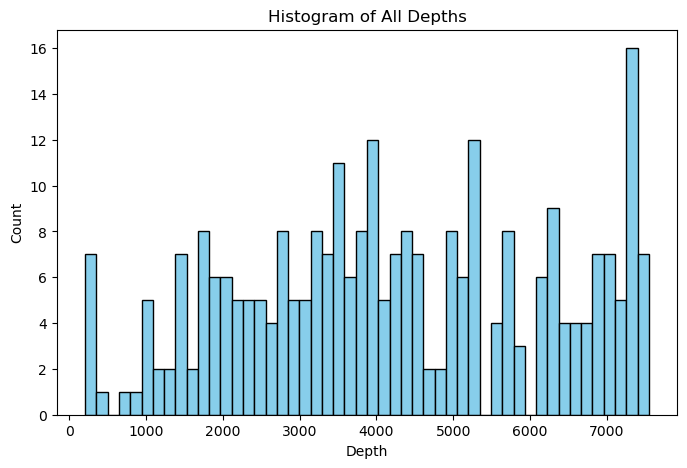

Insertion IDs with depth > 0: []
Neuron (insertion_idx, neuron_idx, unit_id_in_spike_times, region, opercular) with depth > 0:


In [4]:
# histogram plot
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

plt.figure(figsize=(8,5))
plt.hist([d for session_depths in depthAll for d in session_depths], bins=50, color='skyblue', edgecolor='k')
plt.xlabel('Depth')
plt.ylabel('Count')
plt.title('Histogram of All Depths')
#plt.savefig("depth_histogram.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Find the insertion indices where any neuron has depth > 0
insertion_ids_with_depth_gt_0 = []
for i, session_depths in enumerate(depthAll):
    if any(d < 0 for d in session_depths):
        insertion_ids_with_depth_gt_0.append(i)
print("Insertion IDs with depth > 0:", insertion_ids_with_depth_gt_0)

# Find the indices (in terms of insertion index and neuron index) where neuron depth > 0
# Also show region and opercular status
neuron_ids_with_depth_gt_0 = []
for insertion_idx, session_depths in enumerate(depthAll):
    for neuron_idx, d in enumerate(session_depths):
        if d < 0:
            # Try to extract the original unit_id from indicesAll if available
            try:
                unit_id = indicesAll[insertion_idx][neuron_idx]
            except Exception:
                unit_id = None
            # Try to extract region and opercular status
            try:
                region = region_list[insertion_idx]
            except Exception:
                region = None
            try:
                opercular_status = opercular_list[insertion_idx]
            except Exception:
                opercular_status = None

            neuron_ids_with_depth_gt_0.append({
                'insertion_idx': insertion_idx,
                'neuron_idx': neuron_idx,
                'unit_id_in_spike_times': unit_id,
                'region': region,
                'opercular': opercular_status
            })
print("Neuron (insertion_idx, neuron_idx, unit_id_in_spike_times, region, opercular) with depth > 0:")
for n in neuron_ids_with_depth_gt_0:
    print(n)


In [5]:
# CLUSTERING ANALYSIS - prepare data > define metrics > collect and standardize > cluster



# 1. prepare data
print("\n=== PREPARING DATA FOR CLUSTERING ===")

# Flatten all data into single arrays
waveforms_flat = []
firing_rates_flat = []
bursting_metrics_flat = []
autocorr_vectors_flat = []
spike_times_flat = []  # NEW: Flatten spike times
metadata_flat = []

for insertion_idx in range(len(waveformAll)):
    for neuron_idx in range(len(waveformAll[insertion_idx])):
        waveforms_flat.append(waveformAll[insertion_idx][neuron_idx])
        firing_rates_flat.append(firingRatesAll[insertion_idx][neuron_idx])
        bursting_metrics_flat.append(burstingMetricsAll[insertion_idx][neuron_idx])
        autocorr_vectors_flat.append(autocorrVectorsAll[insertion_idx][neuron_idx])
        spike_times_flat.append(spikeTimesAll[insertion_idx][neuron_idx])  # NEW
        
        metadata_flat.append({
            'insertion_idx': insertion_idx,
            'unit_id': indicesAll[insertion_idx][neuron_idx],  # Store unit_id for proper matching
            'subj': subj_list[insertion_idx],
            'grade': grade_list[insertion_idx],
            'pathology': path_list[insertion_idx],
            'yield': yield_list[insertion_idx],
            'opercular': opercular_list[insertion_idx],
            'region': region_list[insertion_idx],
            'age': age_list[insertion_idx],
            'gender': gender_list[insertion_idx],
            'depth': depthAll[insertion_idx][neuron_idx]
        })

# Convert to numpy arrays
waveforms_array = np.array(waveforms_flat)
firing_rates_array = np.array(firing_rates_flat)
autocorr_vectors_array = np.array(autocorr_vectors_flat)

print(f"Total neurons: {len(waveforms_flat)}")
print(f"Waveform array shape: {waveforms_array.shape}")
print(f"Firing rates array shape: {firing_rates_array.shape}")
print(f"Autocorr vectors array shape: {autocorr_vectors_array.shape}")
print(f"Spike times data: {len(spike_times_flat)} neurons")  # NEW

# Extract individual bursting metrics
burst_indices = np.array([bm['burst_index'] for bm in bursting_metrics_flat])
refractory_violations = np.array([bm['refractory_violation'] for bm in bursting_metrics_flat])
burst_peak_heights = np.array([bm['burst_peak_height'] for bm in bursting_metrics_flat])
burst_peak_widths = np.array([bm['burst_peak_width'] for bm in bursting_metrics_flat])
autocorr_skewness = np.array([bm['autocorr_skewness'] for bm in bursting_metrics_flat])
short_isi_ratios = np.array([bm['short_isi_ratio'] for bm in bursting_metrics_flat])

print(f"\nBursting metrics extracted:")
print(f"Burst indices: mean={np.mean(burst_indices):.3f}, std={np.std(burst_indices):.3f}")
print(f"Refractory violations: mean={np.mean(refractory_violations):.3f}, std={np.std(refractory_violations):.3f}")
print(f"Burst peak heights: mean={np.mean(burst_peak_heights):.3f}, std={np.std(burst_peak_heights):.3f}")
print(f"Burst peak widths: mean={np.mean(burst_peak_widths):.3f}, std={np.std(burst_peak_widths):.3f}")
print(f"Autocorr skewness: mean={np.mean(autocorr_skewness):.3f}, std={np.std(autocorr_skewness):.3f}")
print(f"Short ISI ratios: mean={np.mean(short_isi_ratios):.3f}, std={np.std(short_isi_ratios):.3f}")

# Standardize waveforms
waveform_scaler = StandardScaler()
waveforms_scaled = waveform_scaler.fit_transform(waveforms_array)
print(f"\nWaveforms standardized: shape={waveforms_scaled.shape}")

# Prepare spiking data (firing rates + bursting metrics)
spiking_data = np.column_stack([
    firing_rates_array,
    burst_indices,
    refractory_violations,
    burst_peak_heights,
    burst_peak_widths,
    autocorr_skewness,
    short_isi_ratios
])

# Standardize spiking data
spiking_scaler = StandardScaler()
spiking_data_scaled = spiking_scaler.fit_transform(spiking_data)
print(f"Spiking data standardized: shape={spiking_data_scaled.shape}")

# Prepare combined data (waveforms + spiking metrics)
# First standardize each component separately, then combine
combined_data = np.column_stack([
    waveforms_scaled,
    spiking_data_scaled
])

print(f"Combined data prepared: shape={combined_data.shape}")
print("Data preparation complete!")



### 2. Define metrics
# COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS
# Based on literature review for distinguishing interneurons vs pyramidal neurons

print("\n=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===")
print("Selected metrics based on literature review:")
print("Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time")
print("Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation")

# Import additional libraries for comprehensive analysis
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.patches as mpatches

def calculate_spike_width(waveform):
    """Calculate spike width (trough-to-peak duration)"""
    # Find peak and trough
    peak_idx = np.argmax(waveform)
    trough_idx = np.argmin(waveform)
    
    # Calculate width in samples (assuming 30kHz sampling rate)
    width_samples = abs(peak_idx - trough_idx)
    width_ms = width_samples / 30.0  # Convert to milliseconds
    
    return width_ms

def calculate_spike_amplitude(waveform):
    """Calculate spike amplitude (peak-to-trough amplitude).
    Returns positive if abs(peak) > abs(trough), negative if abs(trough) > abs(peak)."""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    amplitude = peak_amp - trough_amp
    if abs(trough_amp) > abs(peak_amp):
        amplitude = -abs(amplitude)
    return amplitude

def calculate_spike_asymmetry(waveform):
    """Calculate spike asymmetry (peak/trough ratio)"""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    
    # Avoid division by zero
    if abs(trough_amp) < 1e-10:
        return np.inf
    
    asymmetry = abs(peak_amp / trough_amp)
    return asymmetry

def calculate_spike_rise_time(waveform):
    """Calculate spike rise time (baseline to peak)"""
    # Find baseline (first 10% of waveform)
    baseline_end = len(waveform) // 10
    baseline = np.mean(waveform[:baseline_end])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going up
    rising_phase = waveform[:peak_idx]
    baseline_crossings = np.where(np.diff(np.sign(rising_phase - baseline)) > 0)[0]
    
    if len(baseline_crossings) > 0:
        rise_start = baseline_crossings[-1]  # Last crossing before peak
        rise_time_samples = peak_idx - rise_start
        rise_time_ms = rise_time_samples / 30.0  # Convert to milliseconds
    else:
        rise_time_ms = peak_idx / 30.0  # Fallback
    
    return rise_time_ms

def calculate_spike_decay_time(waveform):
    """Calculate spike decay time (peak to baseline)"""
    # Find baseline (last 10% of waveform)
    baseline_start = int(len(waveform) * 0.9)
    baseline = np.mean(waveform[baseline_start:])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going down after peak
    decay_phase = waveform[peak_idx:]
    baseline_crossings = np.where(np.diff(np.sign(decay_phase - baseline)) < 0)[0]
    
    if len(baseline_crossings) > 0:
        decay_end = baseline_crossings[0]  # First crossing after peak
        decay_time_samples = decay_end
        decay_time_ms = decay_time_samples / 30.0  # Convert to milliseconds
    else:
        decay_time_ms = (len(waveform) - peak_idx) / 30.0  # Fallback
    
    return decay_time_ms

def calculate_isi_cv(spike_times):
    """Calculate ISI coefficient of variation"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    if len(isis) == 0:
        return 0
    
    mean_isi = np.mean(isis)
    if mean_isi == 0:
        return 0
    
    cv = np.std(isis) / mean_isi
    return cv

def calculate_isi_violation_rate(spike_times, refractory_period=0.002):
    """Calculate ISI violation rate (spikes within refractory period)"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    violations = np.sum(isis < refractory_period)
    total_spikes = len(spike_times)
    
    violation_rate = violations / total_spikes if total_spikes > 0 else 0
    return violation_rate

def calculate_spike_frequency_adaptation(spike_times, window_size=1.0):
    """Calculate spike frequency adaptation"""
    if len(spike_times) < 10:
        return 0
    
    # Divide spike train into windows
    total_time = spike_times[-1] - spike_times[0]
    n_windows = int(total_time / window_size)
    
    if n_windows < 2:
        return 0
    
    window_firing_rates = []
    for i in range(n_windows):
        window_start = spike_times[0] + i * window_size
        window_end = window_start + window_size
        
        spikes_in_window = np.sum((spike_times >= window_start) & (spike_times < window_end))
        firing_rate = spikes_in_window / window_size
        window_firing_rates.append(firing_rate)
    
    if len(window_firing_rates) < 2:
        return 0
    
    # Calculate adaptation as decrease in firing rate over time
    early_rate = np.mean(window_firing_rates[:len(window_firing_rates)//2])
    late_rate = np.mean(window_firing_rates[len(window_firing_rates)//2:])
    
    if early_rate == 0:
        return 0
    
    adaptation = (early_rate - late_rate) / early_rate
    return adaptation

print("Spike characteristic calculation functions defined!")



### 3. Collect and standarize spike metrics
# COLLECT COMPREHENSIVE SPIKE CHARACTERISTICS DATA (CORRECTED VERSION)
print("\n=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===")

# Initialize lists for comprehensive characteristics
comprehensive_waveform_metrics = []
comprehensive_firing_rate_metrics = []
comprehensive_metadata = []

print("Processing all neurons for comprehensive spike characteristics...")

# Process each neuron to extract comprehensive metrics
for neuron_idx in range(len(waveforms_flat)):
    if neuron_idx % 100 == 0:
        print(f"Processing neuron {neuron_idx+1}/{len(waveforms_flat)}")
    
    # Get waveform
    waveform = waveforms_flat[neuron_idx]
    
    # Calculate waveform characteristics
    spike_width = calculate_spike_width(waveform)
    spike_amplitude = calculate_spike_amplitude(waveform)
    spike_asymmetry = calculate_spike_asymmetry(waveform)
    spike_rise_time = calculate_spike_rise_time(waveform)
    spike_decay_time = calculate_spike_decay_time(waveform)
    
    waveform_metrics = [spike_width, spike_amplitude, spike_asymmetry, spike_rise_time, spike_decay_time]
    comprehensive_waveform_metrics.append(waveform_metrics)
    
    # Get firing rate characteristics
    firing_rate = firing_rates_flat[neuron_idx]
    burst_index = bursting_metrics_flat[neuron_idx]['burst_index']
    
    # Calculate additional firing rate characteristics using actual spike times
    spike_times_unit = spike_times_flat[neuron_idx]
    
    # Calculate ISI CV from actual spike times
    isi_cv = calculate_isi_cv(spike_times_unit)
    
    # Calculate ISI violation rate from actual spike times
    isi_violation_rate = calculate_isi_violation_rate(spike_times_unit)
    
    # Calculate spike frequency adaptation from actual spike times
    spike_frequency_adaptation = calculate_spike_frequency_adaptation(spike_times_unit)
    
    firing_rate_metrics = [firing_rate, burst_index, isi_cv, isi_violation_rate, spike_frequency_adaptation]
    comprehensive_firing_rate_metrics.append(firing_rate_metrics)
    
    # Store metadata
    comprehensive_metadata.append(metadata_flat[neuron_idx])

# Convert to numpy arrays
comprehensive_waveform_array = np.array(comprehensive_waveform_metrics)
comprehensive_firing_rate_array = np.array(comprehensive_firing_rate_metrics)

print(f"\nComprehensive metrics collected:")
print(f"Waveform metrics shape: {comprehensive_waveform_array.shape}")
print(f"Firing rate metrics shape: {comprehensive_firing_rate_array.shape}")

# Display summary statistics
waveform_metric_names = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_metric_names = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']

print("\nWaveform Metrics Summary:")
for i, name in enumerate(waveform_metric_names):
    mean_val = np.mean(comprehensive_waveform_array[:, i])
    std_val = np.std(comprehensive_waveform_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nFiring Rate Metrics Summary:")
for i, name in enumerate(firing_rate_metric_names):
    mean_val = np.mean(comprehensive_firing_rate_array[:, i])
    std_val = np.std(comprehensive_firing_rate_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nComprehensive data collection complete!")

# STANDARDIZE COMPREHENSIVE METRICS AND PREPARE FOR CLUSTERING
print("\n=== STANDARDIZING COMPREHENSIVE METRICS ===")

# Standardize waveform metrics
waveform_scaler_comprehensive = StandardScaler()
comprehensive_waveform_scaled = waveform_scaler_comprehensive.fit_transform(comprehensive_waveform_array)

# Standardize firing rate metrics
firing_rate_scaler_comprehensive = StandardScaler()
comprehensive_firing_rate_scaled = firing_rate_scaler_comprehensive.fit_transform(comprehensive_firing_rate_array)

# Create combined dataset
comprehensive_combined_data = np.column_stack([
    comprehensive_waveform_scaled,
    comprehensive_firing_rate_scaled
])

print(f"Standardized waveform metrics shape: {comprehensive_waveform_scaled.shape}")
print(f"Standardized firing rate metrics shape: {comprehensive_firing_rate_scaled.shape}")
print(f"Combined comprehensive data shape: {comprehensive_combined_data.shape}")



### 4. CLUSTER
# Apply UMAP dimensionality reduction to comprehensive metrics
print("\n=== APPLYING UMAP TO COMPREHENSIVE METRICS ===")

# UMAP parameters
n_neighbors = 15
min_dist = 0.1
n_components = 2
random_state = 42

# UMAP on comprehensive waveform metrics
print("Applying UMAP to comprehensive waveform metrics...")
umap_waveform_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
waveform_comprehensive_umap = umap_waveform_comprehensive.fit_transform(comprehensive_waveform_scaled)

# UMAP on comprehensive firing rate metrics
print("Applying UMAP to comprehensive firing rate metrics...")
umap_firing_rate_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
firing_rate_comprehensive_umap = umap_firing_rate_comprehensive.fit_transform(comprehensive_firing_rate_scaled)

# UMAP on combined comprehensive data
print("Applying UMAP to combined comprehensive data...")
umap_combined_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
combined_comprehensive_umap = umap_combined_comprehensive.fit_transform(comprehensive_combined_data)

print(f"Comprehensive waveform UMAP shape: {waveform_comprehensive_umap.shape}")
print(f"Comprehensive firing rate UMAP shape: {firing_rate_comprehensive_umap.shape}")
print(f"Comprehensive combined UMAP shape: {combined_comprehensive_umap.shape}")

print("UMAP dimensionality reduction complete!")


=== PREPARING DATA FOR CLUSTERING ===
Total neurons: 278
Waveform array shape: (278, 90)
Firing rates array shape: (278,)
Autocorr vectors array shape: (278, 200)
Spike times data: 278 neurons

Bursting metrics extracted:
Burst indices: mean=0.245, std=0.279
Refractory violations: mean=0.004, std=0.006
Burst peak heights: mean=0.016, std=0.017
Burst peak widths: mean=0.012, std=0.005
Autocorr skewness: mean=0.681, std=1.578
Short ISI ratios: mean=0.062, std=0.064

Waveforms standardized: shape=(278, 90)
Spiking data standardized: shape=(278, 7)
Combined data prepared: shape=(278, 97)
Data preparation complete!

=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===
Selected metrics based on literature review:
Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time
Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation
Spike characteristic calculation functions defined!

=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===
Processi


=== COMPREHENSIVE CLUSTERING ANALYSIS ===

--- METHOD 1: UMAP + K-means Clustering ---
Testing optimal k for comprehensive waveform UMAP:
k=2: Silhouette Score = 0.685, Inertia = 13612.3
k=3: Silhouette Score = 0.820, Inertia = 2265.7
k=4: Silhouette Score = 0.624, Inertia = 907.8
k=5: Silhouette Score = 0.587, Inertia = 594.1
k=6: Silhouette Score = 0.592, Inertia = 422.4
k=7: Silhouette Score = 0.603, Inertia = 275.1
Optimal number of clusters: 3
Testing optimal k for comprehensive firing rate UMAP:
k=2: Silhouette Score = 0.414, Inertia = 1325.8
k=3: Silhouette Score = 0.453, Inertia = 759.2
k=4: Silhouette Score = 0.446, Inertia = 527.5
k=5: Silhouette Score = 0.469, Inertia = 382.7
k=6: Silhouette Score = 0.458, Inertia = 304.8
k=7: Silhouette Score = 0.469, Inertia = 243.5
Optimal number of clusters: 7
Testing optimal k for comprehensive combined UMAP:
k=2: Silhouette Score = 0.501, Inertia = 1204.1
k=3: Silhouette Score = 0.416, Inertia = 866.3
k=4: Silhouette Score = 0.464, In

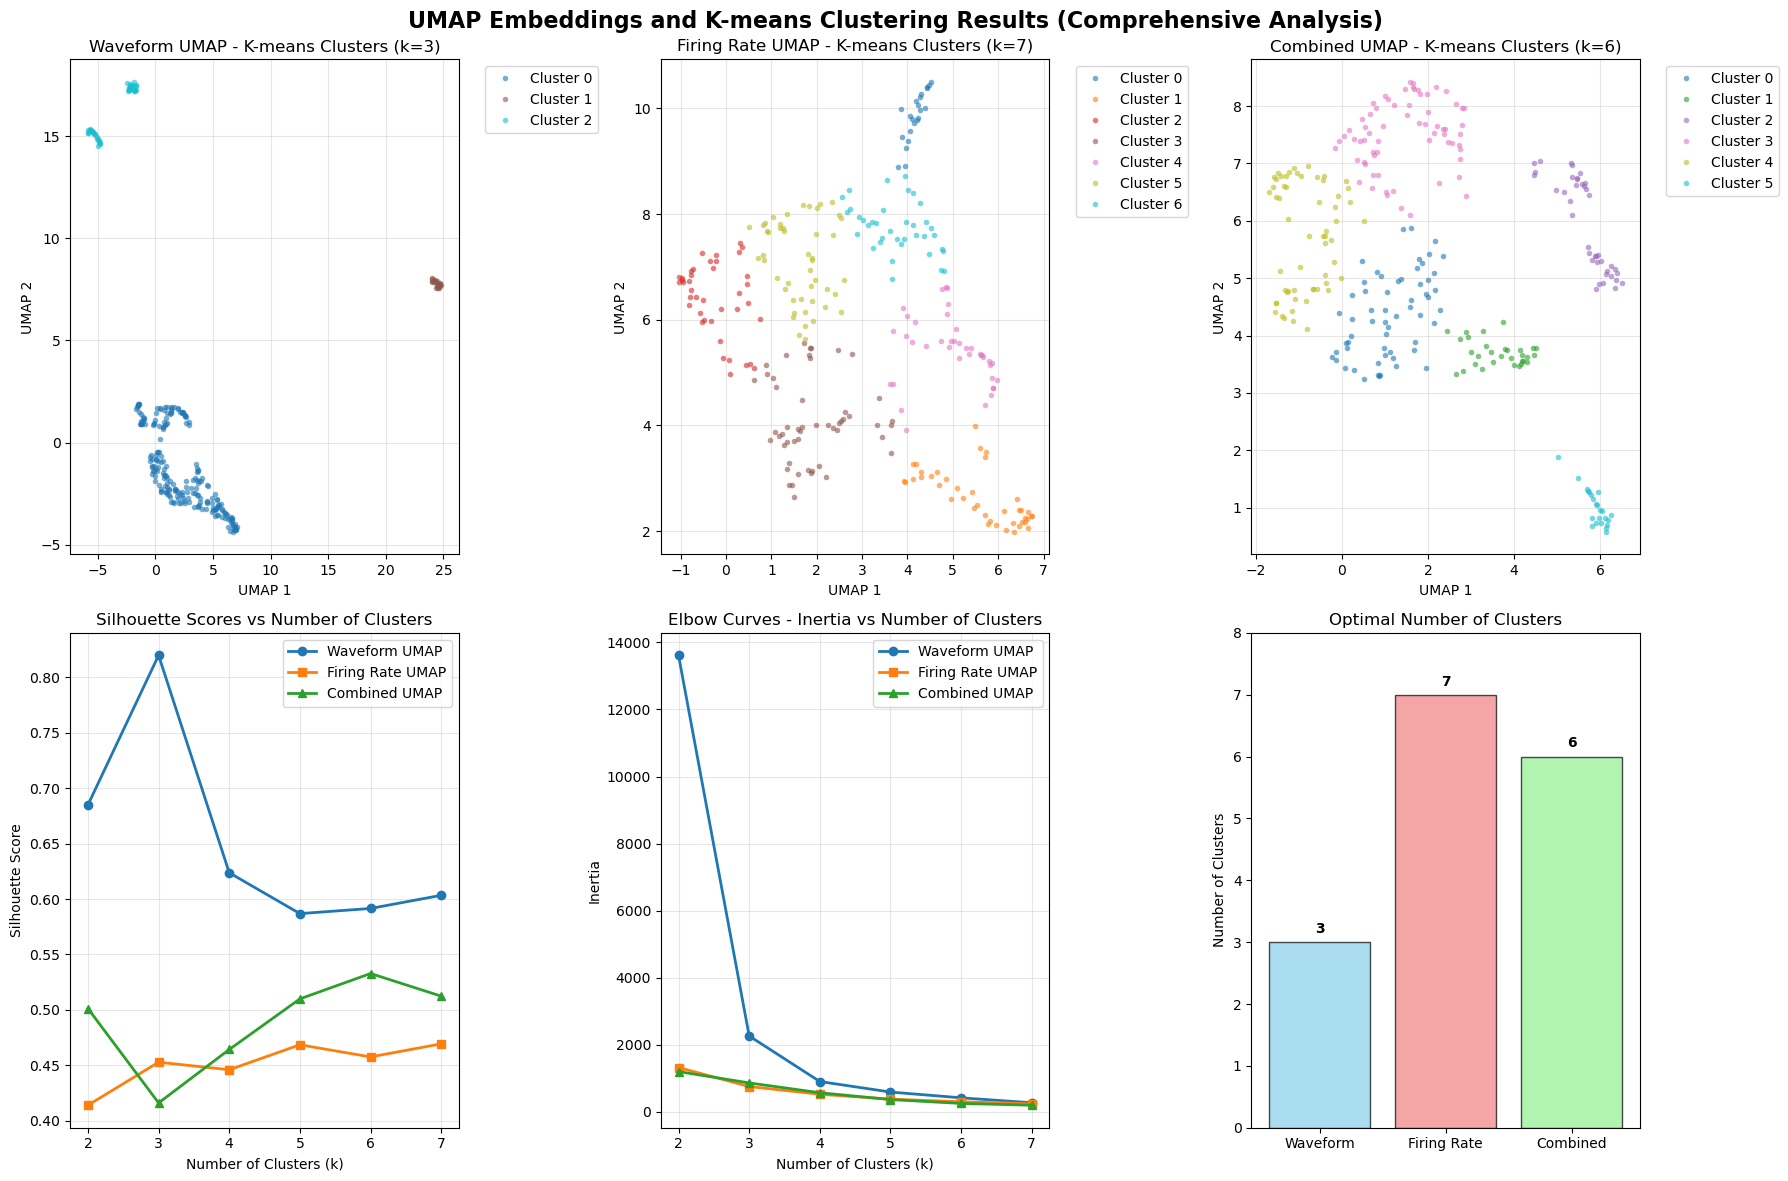


=== DETAILED CLUSTER ANALYSIS ===

Waveform UMAP Cluster Analysis:
  Cluster 0 (n=214):
    Waveform Metrics:
      Spike Width: 0.751 ± 0.158 ms
      Spike Amplitude: -59.523 ± 34.418
      Spike Asymmetry: 0.373 ± 0.184
      Rise Time: 0.387 ± 0.116 ms
      Decay Time: 1.029 ± 0.153 ms
    Firing Rate Metrics:
      Firing Rate: 3.05 ± 2.90 Hz
      Burst Index: 0.222 ± 0.221
      ISI CV: 2.559 ± 1.717
      ISI Violation Rate: 0.004 ± 0.003
      Spike Frequency Adaptation: -0.308 ± 0.724
  Cluster 1 (n=22):
    Waveform Metrics:
      Spike Width: 0.476 ± 0.100 ms
      Spike Amplitude: 87.324 ± 33.111
      Spike Asymmetry: 4.408 ± 1.045
      Rise Time: 0.330 ± 0.171 ms
      Decay Time: 0.202 ± 0.060 ms
    Firing Rate Metrics:
      Firing Rate: 2.07 ± 2.12 Hz
      Burst Index: 0.541 ± 0.507
      ISI CV: 3.800 ± 3.681
      ISI Violation Rate: 0.001 ± 0.003
      Spike Frequency Adaptation: -0.357 ± 0.725
  Cluster 2 (n=42):
    Waveform Metrics:
      Spike Width: 0.224

In [6]:
# COMPREHENSIVE CLUSTERING ANALYSIS
print("\n=== COMPREHENSIVE CLUSTERING ANALYSIS ===")

# Method 1: UMAP + K-means Clustering
print("\n--- METHOD 1: UMAP + K-means Clustering ---")

def find_optimal_k_comprehensive(data, k_range, method_name):
    """Find optimal number of clusters using silhouette score"""
    silhouette_scores = []
    inertias = []
    
    print(f"Testing optimal k for {method_name}:")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        silhouette_avg = silhouette_score(data, labels)
        inertia = kmeans.inertia_
        
        silhouette_scores.append(silhouette_avg)
        inertias.append(inertia)
        
        print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}, Inertia = {inertia:.1f}")
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters: {optimal_k}")
    
    return optimal_k, silhouette_scores, inertias

# Test different k values
k_range = range(2, 8)

# Find optimal k for each UMAP embedding
optimal_k_waveform_comp, silhouette_scores_waveform_comp, inertias_waveform_comp = find_optimal_k_comprehensive(
    waveform_comprehensive_umap, k_range, "comprehensive waveform UMAP"
)

optimal_k_firing_rate_comp, silhouette_scores_firing_rate_comp, inertias_firing_rate_comp = find_optimal_k_comprehensive(
    firing_rate_comprehensive_umap, k_range, "comprehensive firing rate UMAP"
)

optimal_k_combined_comp, silhouette_scores_combined_comp, inertias_combined_comp = find_optimal_k_comprehensive(
    combined_comprehensive_umap, k_range, "comprehensive combined UMAP"
)

# Perform final clustering with optimal k values
print("\nPerforming final UMAP + K-means clustering...")

# Waveform clustering
kmeans_waveform_comp_final = KMeans(n_clusters=optimal_k_waveform_comp, random_state=42, n_init=10)
waveform_comp_labels = kmeans_waveform_comp_final.fit_predict(waveform_comprehensive_umap)
print(f"Comprehensive waveform clustering completed with {optimal_k_waveform_comp} clusters")

# Firing rate clustering
kmeans_firing_rate_comp_final = KMeans(n_clusters=optimal_k_firing_rate_comp, random_state=42, n_init=10)
firing_rate_comp_labels = kmeans_firing_rate_comp_final.fit_predict(firing_rate_comprehensive_umap)
print(f"Comprehensive firing rate clustering completed with {optimal_k_firing_rate_comp} clusters")

# Combined clustering
kmeans_combined_comp_final = KMeans(n_clusters=optimal_k_combined_comp, random_state=42, n_init=10)
combined_comp_labels = kmeans_combined_comp_final.fit_predict(combined_comprehensive_umap)
print(f"Comprehensive combined clustering completed with {optimal_k_combined_comp} clusters")

print("UMAP + K-means clustering complete!")



# VISUALIZE UMAP CLUSTERS FOR ALL METHODS WITH COLOR KEYS
print("\n=== UMAP CLUSTER VISUALIZATIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Create figure with subplots for all UMAP embeddings and clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('UMAP Embeddings and K-means Clustering Results (Comprehensive Analysis)', fontsize=16, fontweight='bold')

# Plot 1: Waveform UMAP with clustering
ax1 = axes[0, 0]
# Use plot instead of scatter for cleaner dots without outlines
for cluster_id in range(optimal_k_waveform_comp):
    mask = waveform_comp_labels == cluster_id
    ax1.plot(waveform_comprehensive_umap[mask, 0], waveform_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_waveform_comp - 1)),
             label=f'Cluster {cluster_id}')
ax1.set_title(f'Waveform UMAP - K-means Clusters (k={optimal_k_waveform_comp})')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Firing Rate UMAP with clustering
ax2 = axes[0, 1]
for cluster_id in range(optimal_k_firing_rate_comp):
    mask = firing_rate_comp_labels == cluster_id
    ax2.plot(firing_rate_comprehensive_umap[mask, 0], firing_rate_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_firing_rate_comp - 1)),
             label=f'Cluster {cluster_id}')
ax2.set_title(f'Firing Rate UMAP - K-means Clusters (k={optimal_k_firing_rate_comp})')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Combined UMAP with clustering
ax3 = axes[0, 2]
for cluster_id in range(optimal_k_combined_comp):
    mask = combined_comp_labels == cluster_id
    ax3.plot(combined_comprehensive_umap[mask, 0], combined_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_combined_comp - 1)),
             label=f'Cluster {cluster_id}')
ax3.set_title(f'Combined UMAP - K-means Clusters (k={optimal_k_combined_comp})')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Silhouette scores comparison
ax4 = axes[1, 0]
ax4.plot(k_range, silhouette_scores_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax4.set_title('Silhouette Scores vs Number of Clusters')
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Silhouette Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Elbow curves comparison
ax5 = axes[1, 1]
ax5.plot(k_range, inertias_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax5.set_title('Elbow Curves - Inertia vs Number of Clusters')
ax5.set_xlabel('Number of Clusters (k)')
ax5.set_ylabel('Inertia')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Cluster size comparison
ax6 = axes[1, 2]
cluster_counts = [optimal_k_waveform_comp, optimal_k_firing_rate_comp, optimal_k_combined_comp]
methods = ['Waveform', 'Firing Rate', 'Combined']
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax6.bar(methods, cluster_counts, color=colors, alpha=0.7, edgecolor='black')
ax6.set_title('Optimal Number of Clusters')
ax6.set_ylabel('Number of Clusters')
ax6.set_ylim(0, max(cluster_counts) + 1)

# Add value labels on bars
for bar, count in zip(bars, cluster_counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("cluster_results.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed cluster analysis
print("\n=== DETAILED CLUSTER ANALYSIS ===")

def analyze_cluster_characteristics_comprehensive(labels, data_name, n_clusters, waveform_data, firing_rate_data):
    """Analyze characteristics of each cluster"""
    print(f"\n{data_name} Cluster Analysis:")
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_size = np.sum(cluster_mask)
        
        if cluster_size > 0:
            # Analyze waveform characteristics for this cluster
            cluster_waveform_metrics = comprehensive_waveform_array[cluster_mask]
            cluster_firing_rate_metrics = comprehensive_firing_rate_array[cluster_mask]
            
            print(f"  Cluster {cluster_id} (n={cluster_size}):")
            
            # Waveform characteristics
            print(f"    Waveform Metrics:")
            print(f"      Spike Width: {np.mean(cluster_waveform_metrics[:, 0]):.3f} ± {np.std(cluster_waveform_metrics[:, 0]):.3f} ms")
            print(f"      Spike Amplitude: {np.mean(cluster_waveform_metrics[:, 1]):.3f} ± {np.std(cluster_waveform_metrics[:, 1]):.3f}")
            print(f"      Spike Asymmetry: {np.mean(cluster_waveform_metrics[:, 2]):.3f} ± {np.std(cluster_waveform_metrics[:, 2]):.3f}")
            print(f"      Rise Time: {np.mean(cluster_waveform_metrics[:, 3]):.3f} ± {np.std(cluster_waveform_metrics[:, 3]):.3f} ms")
            print(f"      Decay Time: {np.mean(cluster_waveform_metrics[:, 4]):.3f} ± {np.std(cluster_waveform_metrics[:, 4]):.3f} ms")
            
            # Firing rate characteristics
            print(f"    Firing Rate Metrics:")
            print(f"      Firing Rate: {np.mean(cluster_firing_rate_metrics[:, 0]):.2f} ± {np.std(cluster_firing_rate_metrics[:, 0]):.2f} Hz")
            print(f"      Burst Index: {np.mean(cluster_firing_rate_metrics[:, 1]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 1]):.3f}")
            print(f"      ISI CV: {np.mean(cluster_firing_rate_metrics[:, 2]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 2]):.3f}")
            print(f"      ISI Violation Rate: {np.mean(cluster_firing_rate_metrics[:, 3]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 3]):.3f}")
            print(f"      Spike Frequency Adaptation: {np.mean(cluster_firing_rate_metrics[:, 4]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 4]):.3f}")

# Analyze each clustering method
analyze_cluster_characteristics_comprehensive(waveform_comp_labels, "Waveform UMAP", optimal_k_waveform_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(firing_rate_comp_labels, "Firing Rate UMAP", optimal_k_firing_rate_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(combined_comp_labels, "Combined UMAP", optimal_k_combined_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)

print("\nUMAP cluster visualizations complete!")


=== COMPREHENSIVE CLUSTERING ANALYSIS ===

--- METHOD 1: UMAP + K-means Clustering ---
Testing optimal k for comprehensive waveform UMAP:
k=2: Silhouette Score = 0.685, Inertia = 13612.3
k=3: Silhouette Score = 0.820, Inertia = 2265.7
k=4: Silhouette Score = 0.624, Inertia = 907.8
k=5: Silhouette Score = 0.587, Inertia = 594.1
k=6: Silhouette Score = 0.592, Inertia = 422.4
k=7: Silhouette Score = 0.603, Inertia = 275.1
Optimal number of clusters: 3
Testing optimal k for comprehensive firing rate UMAP:
k=2: Silhouette Score = 0.414, Inertia = 1325.8
k=3: Silhouette Score = 0.453, Inertia = 759.2
k=4: Silhouette Score = 0.446, Inertia = 527.5
k=5: Silhouette Score = 0.469, Inertia = 382.7
k=6: Silhouette Score = 0.458, Inertia = 304.8
k=7: Silhouette Score = 0.469, Inertia = 243.5
Optimal number of clusters: 7
Testing optimal k for comprehensive combined UMAP:
k=2: Silhouette Score = 0.501, Inertia = 1204.1
k=3: Silhouette Score = 0.416, Inertia = 866.3
k=4: Silhouette Score = 0.464, In

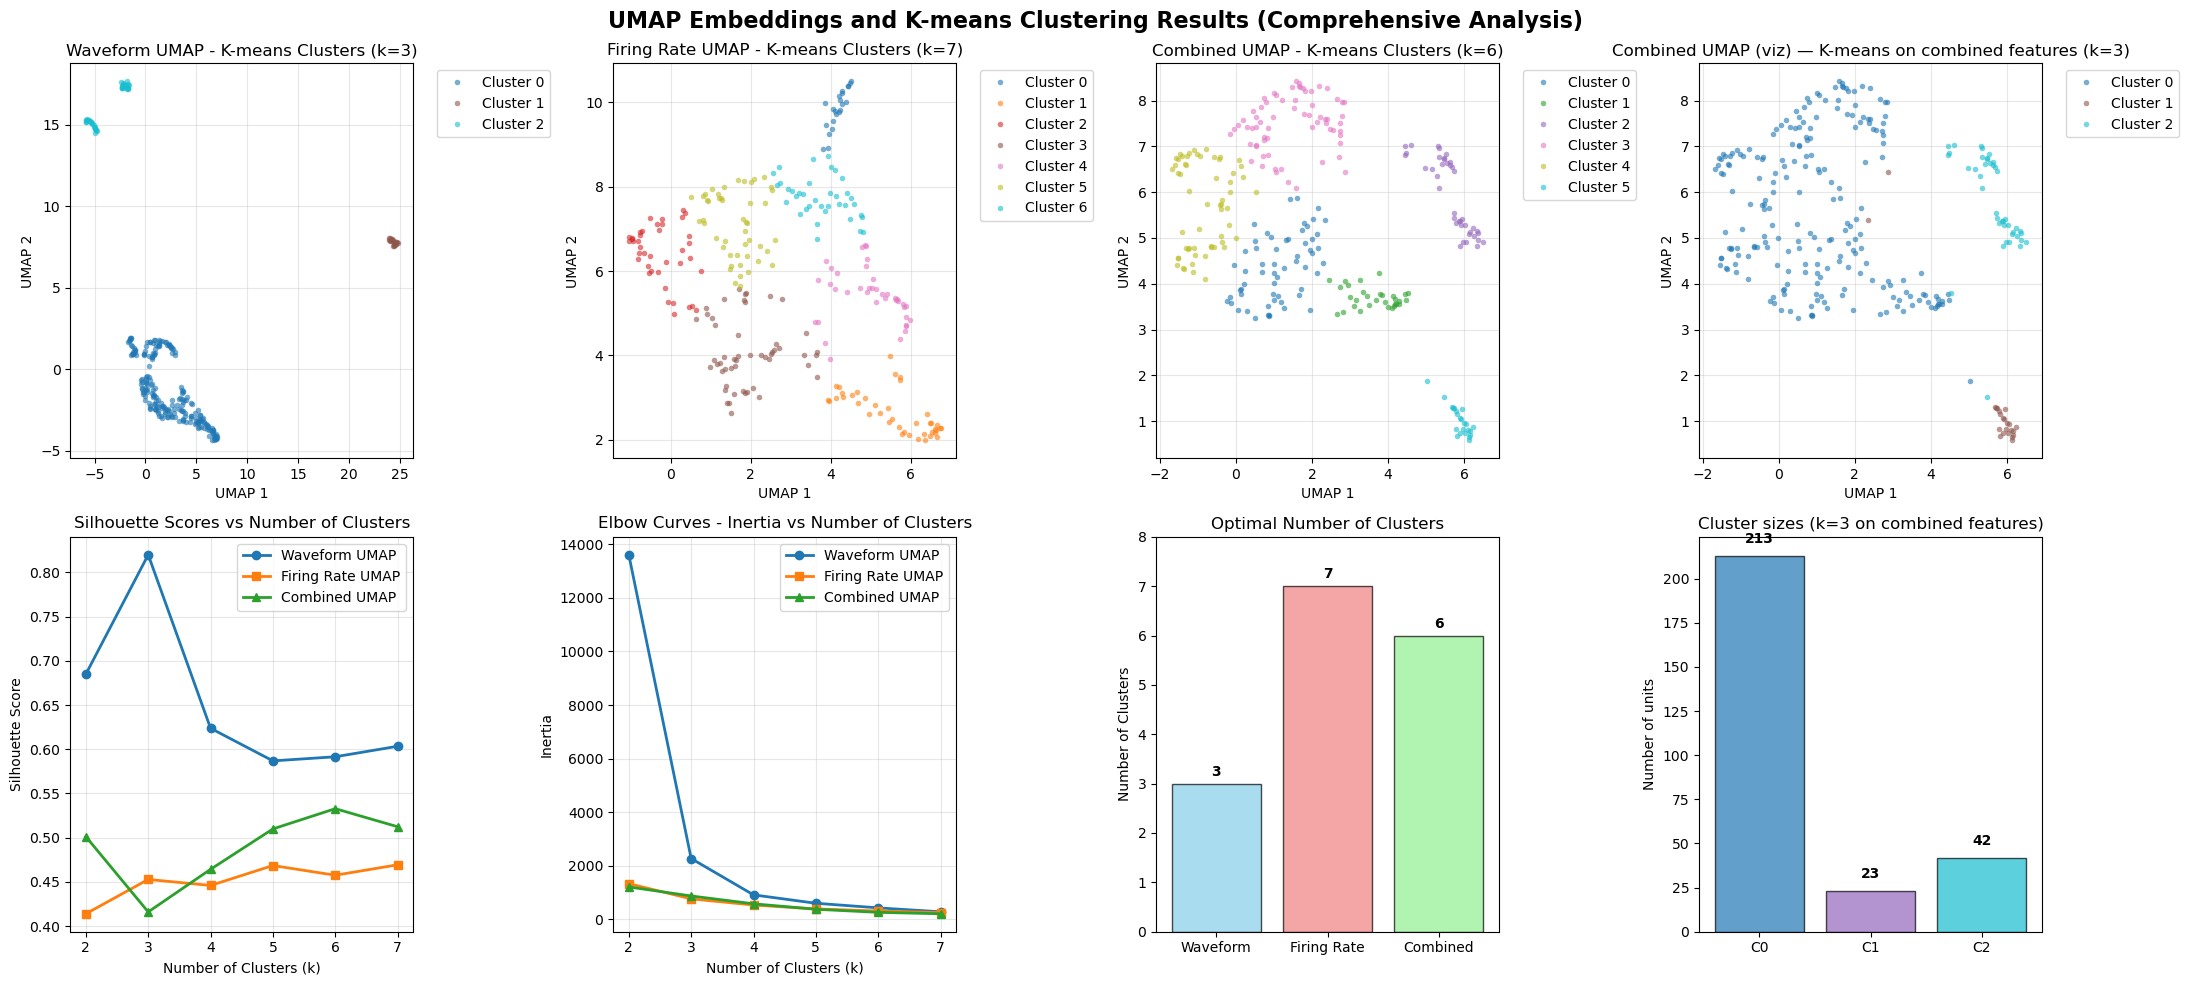


=== DETAILED CLUSTER ANALYSIS ===

Waveform UMAP Cluster Analysis:
  Cluster 0 (n=214):
    Waveform Metrics:
      Spike Width: 0.751 ± 0.158 ms
      Spike Amplitude: -59.523 ± 34.418
      Spike Asymmetry: 0.373 ± 0.184
      Rise Time: 0.387 ± 0.116 ms
      Decay Time: 1.029 ± 0.153 ms
    Firing Rate Metrics:
      Firing Rate: 3.05 ± 2.90 Hz
      Burst Index: 0.222 ± 0.221
      ISI CV: 2.559 ± 1.717
      ISI Violation Rate: 0.004 ± 0.003
      Spike Frequency Adaptation: -0.308 ± 0.724
  Cluster 1 (n=22):
    Waveform Metrics:
      Spike Width: 0.476 ± 0.100 ms
      Spike Amplitude: 87.324 ± 33.111
      Spike Asymmetry: 4.408 ± 1.045
      Rise Time: 0.330 ± 0.171 ms
      Decay Time: 0.202 ± 0.060 ms
    Firing Rate Metrics:
      Firing Rate: 2.07 ± 2.12 Hz
      Burst Index: 0.541 ± 0.507
      ISI CV: 3.800 ± 3.681
      ISI Violation Rate: 0.001 ± 0.003
      Spike Frequency Adaptation: -0.357 ± 0.725
  Cluster 2 (n=42):
    Waveform Metrics:
      Spike Width: 0.224

In [7]:
# COMPREHENSIVE CLUSTERING ANALYSIS
print("\n=== COMPREHENSIVE CLUSTERING ANALYSIS ===")

# Method 1: UMAP + K-means Clustering
print("\n--- METHOD 1: UMAP + K-means Clustering ---")

def find_optimal_k_comprehensive(data, k_range, method_name):
    """Find optimal number of clusters using silhouette score"""
    silhouette_scores = []
    inertias = []
    
    print(f"Testing optimal k for {method_name}:")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        silhouette_avg = silhouette_score(data, labels)
        inertia = kmeans.inertia_
        
        silhouette_scores.append(silhouette_avg)
        inertias.append(inertia)
        
        print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}, Inertia = {inertia:.1f}")
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters: {optimal_k}")
    
    return optimal_k, silhouette_scores, inertias

# Test different k values
k_range = range(2, 8)

# Find optimal k for each UMAP embedding
optimal_k_waveform_comp, silhouette_scores_waveform_comp, inertias_waveform_comp = find_optimal_k_comprehensive(
    waveform_comprehensive_umap, k_range, "comprehensive waveform UMAP"
)

optimal_k_firing_rate_comp, silhouette_scores_firing_rate_comp, inertias_firing_rate_comp = find_optimal_k_comprehensive(
    firing_rate_comprehensive_umap, k_range, "comprehensive firing rate UMAP"
)

optimal_k_combined_comp, silhouette_scores_combined_comp, inertias_combined_comp = find_optimal_k_comprehensive(
    combined_comprehensive_umap, k_range, "comprehensive combined UMAP"
)

# Perform final clustering with optimal k values
print("\nPerforming final UMAP + K-means clustering...")

# Waveform clustering
kmeans_waveform_comp_final = KMeans(n_clusters=optimal_k_waveform_comp, random_state=42, n_init=10)
waveform_comp_labels = kmeans_waveform_comp_final.fit_predict(waveform_comprehensive_umap)
print(f"Comprehensive waveform clustering completed with {optimal_k_waveform_comp} clusters")

# Firing rate clustering
kmeans_firing_rate_comp_final = KMeans(n_clusters=optimal_k_firing_rate_comp, random_state=42, n_init=10)
firing_rate_comp_labels = kmeans_firing_rate_comp_final.fit_predict(firing_rate_comprehensive_umap)
print(f"Comprehensive firing rate clustering completed with {optimal_k_firing_rate_comp} clusters")

# Combined clustering
kmeans_combined_comp_final = KMeans(n_clusters=optimal_k_combined_comp, random_state=42, n_init=10)
combined_comp_labels = kmeans_combined_comp_final.fit_predict(combined_comprehensive_umap)
print(f"Comprehensive combined clustering completed with {optimal_k_combined_comp} clusters")

# Additional method: fixed k=3 on combined standardized waveform + firing-rate features (not UMAP space)
print("\n--- ADDITIONAL: K-means (k=3) on combined waveform + rate features ---")
kmeans_combined_k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
combined_k3_labels = kmeans_combined_k3.fit_predict(comprehensive_combined_data)
print(f"K-means k=3 on combined features — cluster sizes: {np.bincount(combined_k3_labels, minlength=3)}")

print("UMAP + K-means clustering complete!")



# VISUALIZE UMAP CLUSTERS FOR ALL METHODS WITH COLOR KEYS
print("\n=== UMAP CLUSTER VISUALIZATIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Create figure with subplots for all UMAP embeddings and clustering results
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('UMAP Embeddings and K-means Clustering Results (Comprehensive Analysis)', fontsize=16, fontweight='bold')

# Plot 1: Waveform UMAP with clustering
ax1 = axes[0, 0]
# Use plot instead of scatter for cleaner dots without outlines
for cluster_id in range(optimal_k_waveform_comp):
    mask = waveform_comp_labels == cluster_id
    ax1.plot(waveform_comprehensive_umap[mask, 0], waveform_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_waveform_comp - 1)),
             label=f'Cluster {cluster_id}')
ax1.set_title(f'Waveform UMAP - K-means Clusters (k={optimal_k_waveform_comp})')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Firing Rate UMAP with clustering
ax2 = axes[0, 1]
for cluster_id in range(optimal_k_firing_rate_comp):
    mask = firing_rate_comp_labels == cluster_id
    ax2.plot(firing_rate_comprehensive_umap[mask, 0], firing_rate_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_firing_rate_comp - 1)),
             label=f'Cluster {cluster_id}')
ax2.set_title(f'Firing Rate UMAP - K-means Clusters (k={optimal_k_firing_rate_comp})')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Combined UMAP with clustering
ax3 = axes[0, 2]
for cluster_id in range(optimal_k_combined_comp):
    mask = combined_comp_labels == cluster_id
    ax3.plot(combined_comprehensive_umap[mask, 0], combined_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_combined_comp - 1)),
             label=f'Cluster {cluster_id}')
ax3.set_title(f'Combined UMAP - K-means Clusters (k={optimal_k_combined_comp})')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Combined UMAP colored by k=3 clusters (fit on combined waveform + rate features)
ax_k3 = axes[0, 3]
for cluster_id in range(3):
    mask = combined_k3_labels == cluster_id
    ax_k3.plot(combined_comprehensive_umap[mask, 0], combined_comprehensive_umap[mask, 1],
               'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
               color=plt.cm.tab10(cluster_id / 2),
               label=f'Cluster {cluster_id}')
ax_k3.set_title('Combined UMAP (viz) — K-means on combined features (k=3)')
ax_k3.set_xlabel('UMAP 1')
ax_k3.set_ylabel('UMAP 2')
ax_k3.grid(True, alpha=0.3)
ax_k3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 5: Silhouette scores comparison
ax4 = axes[1, 0]
ax4.plot(k_range, silhouette_scores_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax4.set_title('Silhouette Scores vs Number of Clusters')
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Silhouette Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 6: Elbow curves comparison
ax5 = axes[1, 1]
ax5.plot(k_range, inertias_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax5.set_title('Elbow Curves - Inertia vs Number of Clusters')
ax5.set_xlabel('Number of Clusters (k)')
ax5.set_ylabel('Inertia')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 7: Cluster size comparison (optimal k from silhouette)
ax6 = axes[1, 2]
cluster_counts = [optimal_k_waveform_comp, optimal_k_firing_rate_comp, optimal_k_combined_comp]
methods = ['Waveform', 'Firing Rate', 'Combined']
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax6.bar(methods, cluster_counts, color=colors, alpha=0.7, edgecolor='black')
ax6.set_title('Optimal Number of Clusters')
ax6.set_ylabel('Number of Clusters')
ax6.set_ylim(0, max(cluster_counts) + 1)

# Add value labels on bars
for bar, count in zip(bars, cluster_counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontweight='bold')

# Plot 8: Cluster sizes for k=3 combined-feature clustering
ax7 = axes[1, 3]
k3_sizes = np.bincount(combined_k3_labels, minlength=3)
bars_k3 = ax7.bar([f'C{i}' for i in range(3)], k3_sizes, color=plt.cm.tab10(np.linspace(0, 0.9, 3)), alpha=0.7, edgecolor='black')
ax7.set_title('Cluster sizes (k=3 on combined features)')
ax7.set_ylabel('Number of units')
for bar, count in zip(bars_k3, k3_sizes):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(1, 0.02 * np.sum(k3_sizes)),
             str(int(count)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("cluster_results.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed cluster analysis
print("\n=== DETAILED CLUSTER ANALYSIS ===")

def analyze_cluster_characteristics_comprehensive(labels, data_name, n_clusters, waveform_data, firing_rate_data):
    """Analyze characteristics of each cluster"""
    print(f"\n{data_name} Cluster Analysis:")
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_size = np.sum(cluster_mask)
        
        if cluster_size > 0:
            # Analyze waveform characteristics for this cluster
            cluster_waveform_metrics = comprehensive_waveform_array[cluster_mask]
            cluster_firing_rate_metrics = comprehensive_firing_rate_array[cluster_mask]
            
            print(f"  Cluster {cluster_id} (n={cluster_size}):")
            
            # Waveform characteristics
            print(f"    Waveform Metrics:")
            print(f"      Spike Width: {np.mean(cluster_waveform_metrics[:, 0]):.3f} ± {np.std(cluster_waveform_metrics[:, 0]):.3f} ms")
            print(f"      Spike Amplitude: {np.mean(cluster_waveform_metrics[:, 1]):.3f} ± {np.std(cluster_waveform_metrics[:, 1]):.3f}")
            print(f"      Spike Asymmetry: {np.mean(cluster_waveform_metrics[:, 2]):.3f} ± {np.std(cluster_waveform_metrics[:, 2]):.3f}")
            print(f"      Rise Time: {np.mean(cluster_waveform_metrics[:, 3]):.3f} ± {np.std(cluster_waveform_metrics[:, 3]):.3f} ms")
            print(f"      Decay Time: {np.mean(cluster_waveform_metrics[:, 4]):.3f} ± {np.std(cluster_waveform_metrics[:, 4]):.3f} ms")
            
            # Firing rate characteristics
            print(f"    Firing Rate Metrics:")
            print(f"      Firing Rate: {np.mean(cluster_firing_rate_metrics[:, 0]):.2f} ± {np.std(cluster_firing_rate_metrics[:, 0]):.2f} Hz")
            print(f"      Burst Index: {np.mean(cluster_firing_rate_metrics[:, 1]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 1]):.3f}")
            print(f"      ISI CV: {np.mean(cluster_firing_rate_metrics[:, 2]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 2]):.3f}")
            print(f"      ISI Violation Rate: {np.mean(cluster_firing_rate_metrics[:, 3]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 3]):.3f}")
            print(f"      Spike Frequency Adaptation: {np.mean(cluster_firing_rate_metrics[:, 4]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 4]):.3f}")

# Analyze each clustering method
analyze_cluster_characteristics_comprehensive(waveform_comp_labels, "Waveform UMAP", optimal_k_waveform_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(firing_rate_comp_labels, "Firing Rate UMAP", optimal_k_firing_rate_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(combined_comp_labels, "Combined UMAP", optimal_k_combined_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(combined_k3_labels, "Combined features K-means (k=3)", 3,
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)

print("\nUMAP cluster visualizations complete!")


=== VISUALIZATION: K=3 COMBINED FEATURES ===


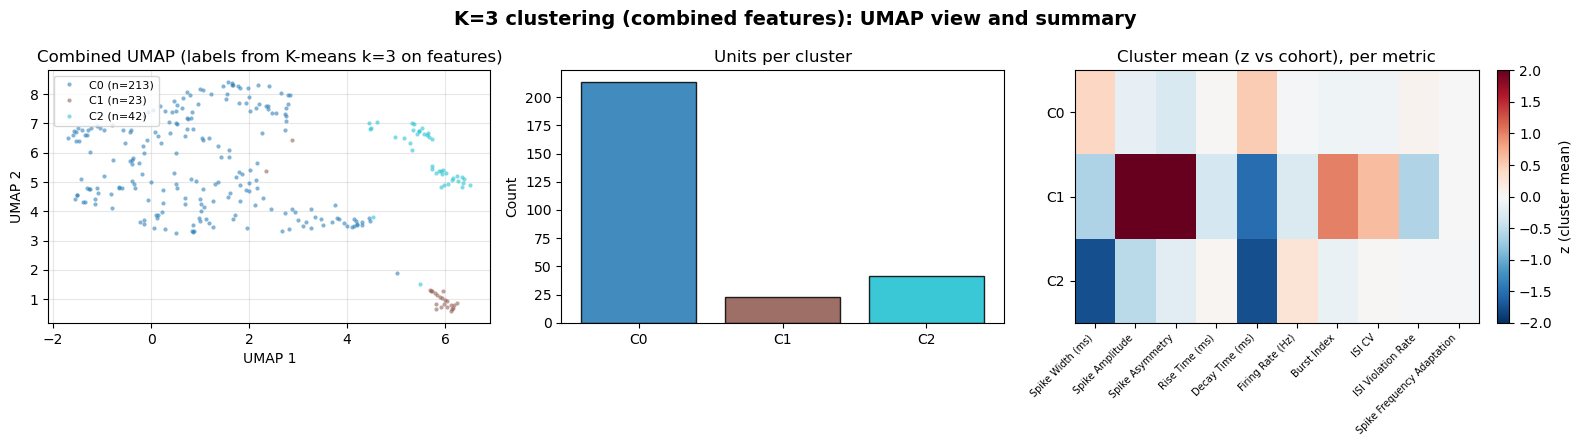

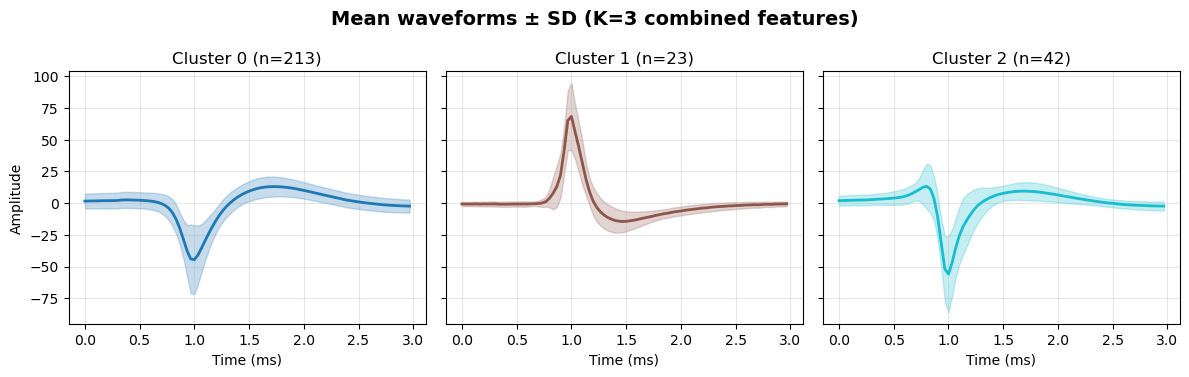

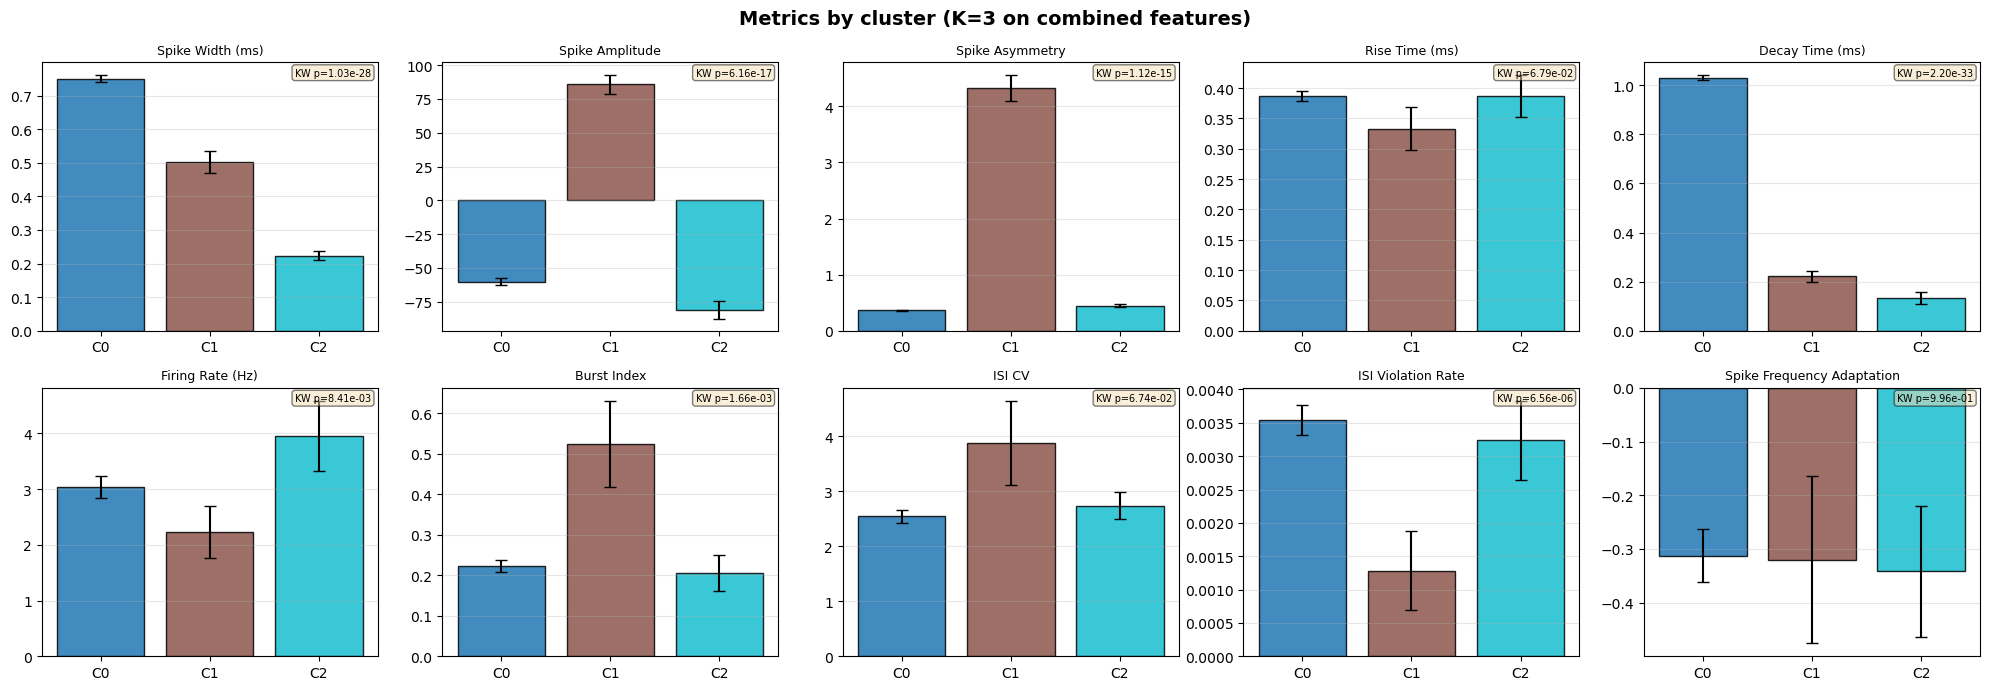

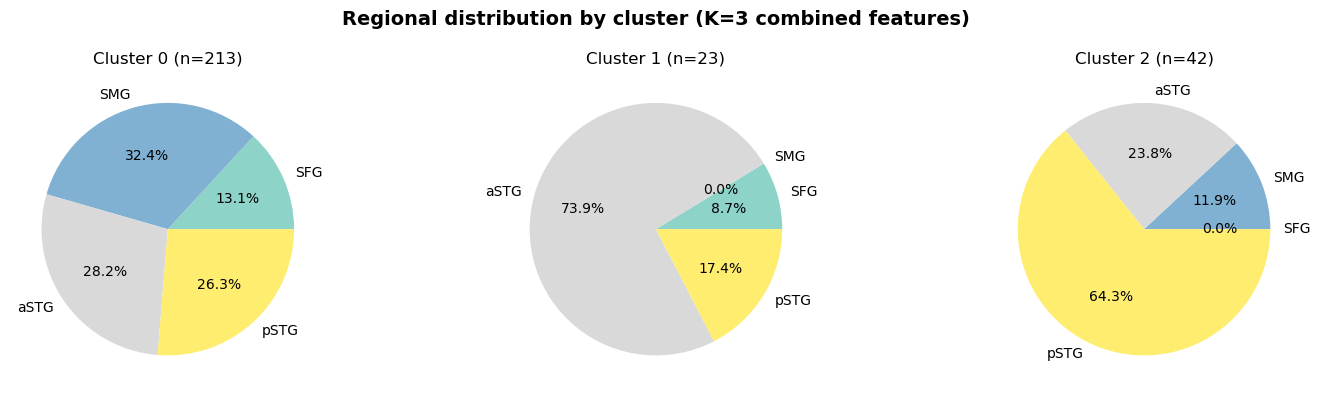

Saved: cluster_k3_combined_summary.svg, cluster_k3_combined_waveforms.svg, cluster_k3_combined_metrics_bars.svg, cluster_k3_combined_regions.svg


In [11]:
# VISUALIZATION — K=3 combined waveform + rate features (K-means on `comprehensive_combined_data`)
# Run after the comprehensive clustering cell (`combined_k3_labels`, UMAP, metric arrays).

print("\n=== VISUALIZATION: K=3 COMBINED FEATURES ===")
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal

waveform_vars = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_vars = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']
all_vars = waveform_vars + firing_rate_vars

waveforms_viz = np.array(waveforms_flat)
combined_metrics = np.hstack([comprehensive_waveform_array, comprehensive_firing_rate_array])
n_k = 3
labels = combined_k3_labels
umap_xy = combined_comprehensive_umap

# --- Figure 1: UMAP + cluster sizes + heatmap of cluster means (z-scored per variable for color) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 4.5))
fig1.suptitle('K=3 clustering (combined features): UMAP view and summary', fontsize=14, fontweight='bold')

ax = axes1[0]
for c in range(n_k):
    m = labels == c
    ax.plot(umap_xy[m, 0], umap_xy[m, 1], 'o', alpha=0.55, markersize=3, markeredgewidth=0,
            color=plt.cm.tab10(c / 2), label=f'C{c} (n={np.sum(m)})')
ax.set_title('Combined UMAP (labels from K-means k=3 on features)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

counts = np.bincount(labels, minlength=n_k)
axes1[1].bar([f'C{i}' for i in range(n_k)], counts, color=[plt.cm.tab10(i / 2) for i in range(n_k)], edgecolor='k', alpha=0.85)
axes1[1].set_title('Units per cluster')
axes1[1].set_ylabel('Count')

# Heatmap: rows = cluster, cols = variable; color = z-score of cluster mean relative to global mean/std
global_mean = np.mean(combined_metrics, axis=0)
global_std = np.std(combined_metrics, axis=0, ddof=0)
global_std = np.where(global_std < 1e-12, 1.0, global_std)
Z = np.zeros((n_k, combined_metrics.shape[1]))
for c in range(n_k):
    m = labels == c
    if np.any(m):
        Z[c, :] = (np.mean(combined_metrics[m], axis=0) - global_mean) / global_std
im = axes1[2].imshow(Z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
axes1[2].set_xticks(np.arange(len(all_vars)))
axes1[2].set_xticklabels(all_vars, rotation=45, ha='right', fontsize=7)
axes1[2].set_yticks(range(n_k))
axes1[2].set_yticklabels([f'C{i}' for i in range(n_k)])
axes1[2].set_title('Cluster mean (z vs cohort), per metric')
plt.colorbar(im, ax=axes1[2], fraction=0.046, pad=0.04, label='z (cluster mean)')
plt.tight_layout()
plt.savefig("cluster_k3_combined_summary.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 2: mean waveforms per cluster ---
fig2, axes2 = plt.subplots(1, n_k, figsize=(4 * n_k, 3.8), sharey=True)
if n_k == 1:
    axes2 = [axes2]
fig2.suptitle('Mean waveforms ± SD (K=3 combined features)', fontsize=14, fontweight='bold')
t_ms = np.arange(waveforms_viz.shape[1]) / 30.0
for c in range(n_k):
    m = labels == c
    w = waveforms_viz[m]
    if len(w) == 0:
        continue
    mu = np.mean(w, axis=0)
    sd = np.std(w, axis=0)
    axes2[c].plot(t_ms, mu, color=plt.cm.tab10(c / 2), lw=2)
    axes2[c].fill_between(t_ms, mu - sd, mu + sd, color=plt.cm.tab10(c / 2), alpha=0.25)
    axes2[c].set_title(f'Cluster {c} (n={len(w)})')
    axes2[c].set_xlabel('Time (ms)')
    axes2[c].grid(True, alpha=0.3)
axes2[0].set_ylabel('Amplitude')
plt.tight_layout()
plt.savefig("cluster_k3_combined_waveforms.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 3: bar plots + Kruskal–Wallis p-value per metric ---
fig3, axes3 = plt.subplots(2, 5, figsize=(20, 7))
fig3.suptitle('Metrics by cluster (K=3 on combined features)', fontsize=14, fontweight='bold')
axes3f = axes3.flatten()
colors = [plt.cm.tab10(i / 2) for i in range(n_k)]
for j in range(combined_metrics.shape[1]):
    ax = axes3f[j]
    means, sems = [], []
    for c in range(n_k):
        x = combined_metrics[labels == c, j]
        means.append(np.mean(x) if len(x) else np.nan)
        sems.append(np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0)
    xpos = np.arange(n_k)
    ax.bar(xpos, means, yerr=sems, capsize=4, color=colors, edgecolor='k', alpha=0.85)
    ax.set_xticks(xpos)
    ax.set_xticklabels([f'C{i}' for i in range(n_k)])
    ax.set_title(all_vars[j], fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    groups = [combined_metrics[labels == c, j] for c in range(n_k) if np.sum(labels == c) > 0]
    if len(groups) >= 2:
        try:
            _, p_kw = kruskal(*groups)
            ax.text(0.98, 0.98, f'KW p={p_kw:.2e}', transform=ax.transAxes, ha='right', va='top', fontsize=7,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        except ValueError:
            pass
plt.tight_layout()
plt.savefig("cluster_k3_combined_metrics_bars.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# --- Figure 4: regional composition per cluster (pie) ---
regions_all = [meta['region'] for meta in comprehensive_metadata]
uniq = sorted(set(regions_all))
fig4, axes4 = plt.subplots(1, n_k, figsize=(5 * n_k, 4))
if n_k == 1:
    axes4 = [axes4]
fig4.suptitle('Regional distribution by cluster (K=3 combined features)', fontsize=14, fontweight='bold')
cmap = plt.cm.Set3(np.linspace(0, 1, max(len(uniq), 1)))
for c in range(n_k):
    m = labels == c
    sub = [regions_all[i] for i in range(len(regions_all)) if m[i]]
    if not sub:
        axes4[c].set_visible(False)
        continue
    cnt = {r: sub.count(r) for r in uniq}
    sizes = [cnt[r] for r in uniq]
    axes4[c].pie(sizes, labels=uniq, autopct='%1.1f%%', colors=cmap[: len(uniq)])
    axes4[c].set_title(f'Cluster {c} (n={len(sub)})')
plt.tight_layout()
plt.savefig("cluster_k3_combined_regions.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print("Saved: cluster_k3_combined_summary.svg, cluster_k3_combined_waveforms.svg, cluster_k3_combined_metrics_bars.svg, cluster_k3_combined_regions.svg")


=== VARIABLE ANALYSIS BY CLUSTER ===

Spike Width (ms):
  Cluster 0: mean = 0.891 ± 0.099 (n=59)
  Cluster 1: mean = 0.738 ± 0.158 (n=31)
  Cluster 2: mean = 0.225 ± 0.095 (n=40)
  Cluster 1 vs 2: T-test p = 0.0000, Mann-Whitney p = 0.0000

Spike Amplitude:
  Cluster 0: mean = -53.999 ± 23.073 (n=59)
  Cluster 1: mean = -59.103 ± 27.042 (n=31)
  Cluster 2: mean = -82.602 ± 42.173 (n=40)
  Cluster 1 vs 2: T-test p = 0.0096, Mann-Whitney p = 0.0061

Spike Asymmetry:
  Cluster 0: mean = 0.390 ± 0.293 (n=59)
  Cluster 1: mean = 0.381 ± 0.079 (n=31)
  Cluster 2: mean = 0.437 ± 0.169 (n=40)
  Cluster 1 vs 2: T-test p = 0.0971, Mann-Whitney p = 0.2213

Rise Time (ms):
  Cluster 0: mean = 0.510 ± 0.080 (n=59)
  Cluster 1: mean = 0.403 ± 0.108 (n=31)
  Cluster 2: mean = 0.382 ± 0.222 (n=40)
  Cluster 1 vs 2: T-test p = 0.6254, Mann-Whitney p = 0.5415

Decay Time (ms):
  Cluster 0: mean = 0.913 ± 0.100 (n=59)
  Cluster 1: mean = 1.020 ± 0.210 (n=31)
  Cluster 2: mean = 0.135 ± 0.160 (n=40)
  Cl

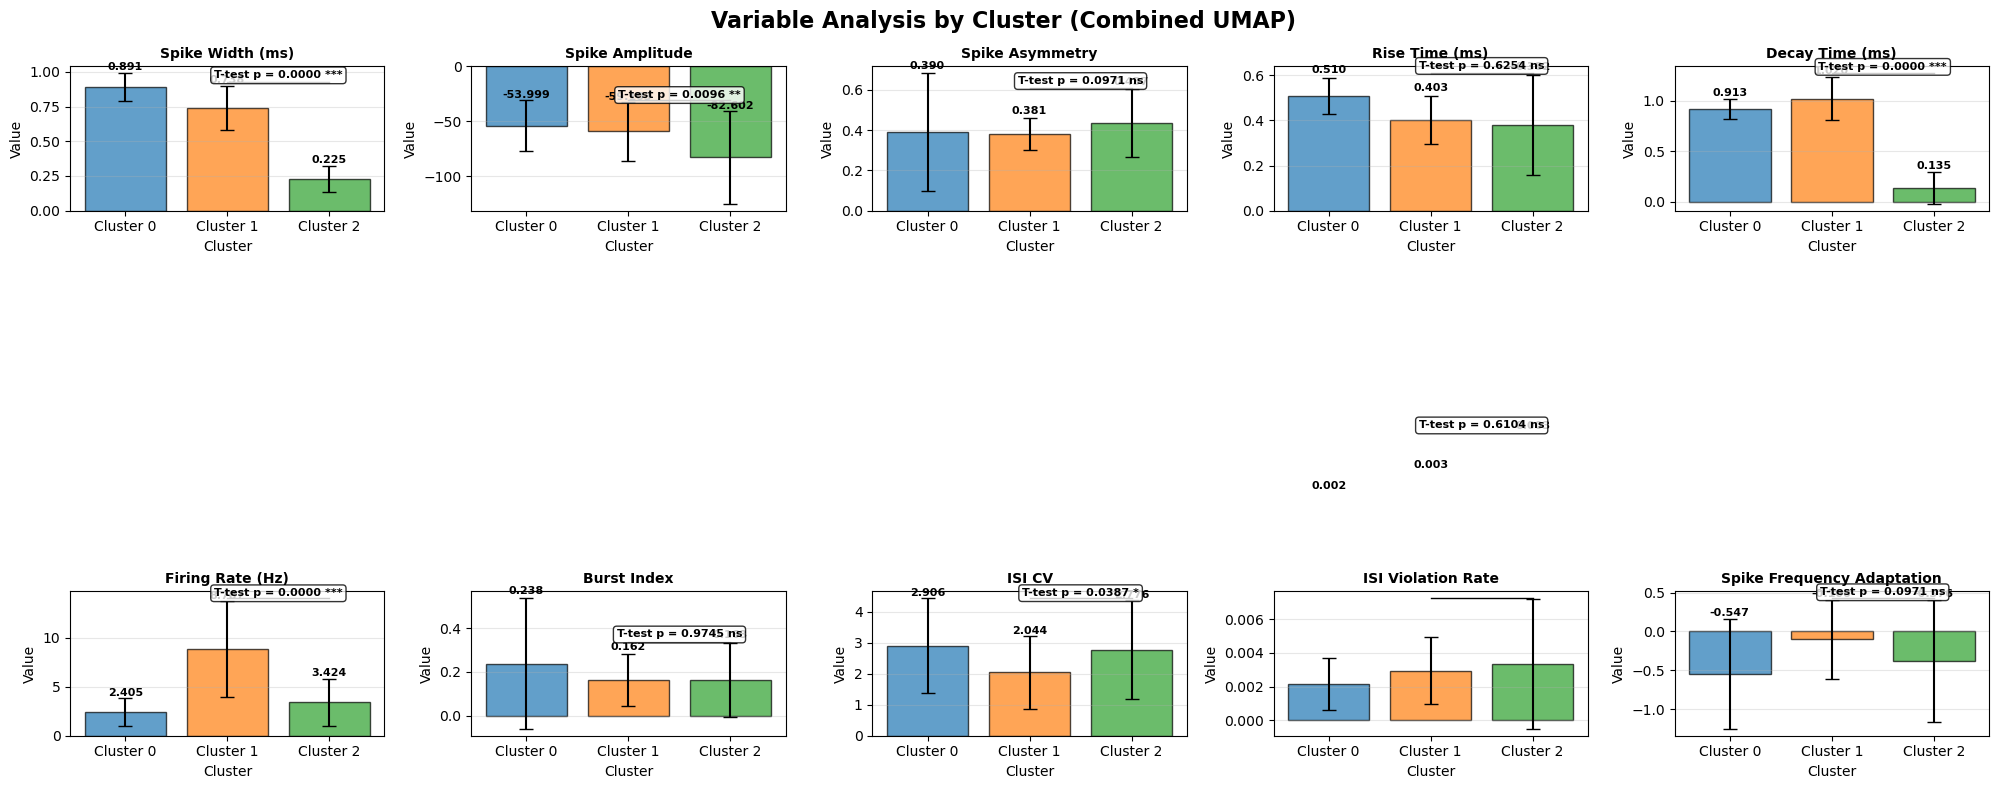


=== SUMMARY STATISTICS TABLE ===
Variable                 	Cluster 0	Cluster 1	Cluster 2
---------------------------------------------------------------------------
Spike Width (ms)         	0.891 ± 0.099	0.738 ± 0.158	0.225 ± 0.095
Spike Amplitude          	-53.999 ± 23.073	-59.103 ± 27.042	-82.602 ± 42.173
Spike Asymmetry          	0.390 ± 0.293	0.381 ± 0.079	0.437 ± 0.169
Rise Time (ms)           	0.510 ± 0.080	0.403 ± 0.108	0.382 ± 0.222
Decay Time (ms)          	0.913 ± 0.100	1.020 ± 0.210	0.135 ± 0.160
Firing Rate (Hz)         	2.405 ± 1.442	8.787 ± 4.881	3.424 ± 2.401
Burst Index              	0.238 ± 0.301	0.162 ± 0.118	0.163 ± 0.172
ISI CV                   	2.906 ± 1.521	2.044 ± 1.169	2.776 ± 1.604
ISI Violation Rate       	0.002 ± 0.002	0.003 ± 0.002	0.003 ± 0.004
Spike Frequency Adaptation	-0.547 ± 0.707	-0.100 ± 0.507	-0.376 ± 0.782

=== STATISTICAL SIGNIFICANCE SUMMARY (Cluster 1 vs 2) ===
Variable			T-test p-value		Mann-Whitney p-value
----------------------------------

In [16]:
# BAR PLOTS FOR ALL VARIABLES BY CLUSTER WITH STATISTICAL TESTS
print("\n=== VARIABLE ANALYSIS BY CLUSTER ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu

# Define variable names
waveform_vars = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_vars = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']
all_vars = waveform_vars + firing_rate_vars

# Get the data arrays
waveform_data = comprehensive_waveform_array  # Shape: (n_neurons, 5)
firing_rate_data = comprehensive_firing_rate_array  # Shape: (n_neurons, 5)
combined_data = np.hstack([waveform_data, firing_rate_data])  # Shape: (n_neurons, 10)

# Get cluster labels
cluster_labels = combined_comp_labels

# Show cluster 0, 1, 2 for plotting,
# but only do statistical tests to compare cluster 1 and 2 (not including 0 in stats)
plot_cluster_ids = [0, 1, 2]
stats_cluster_ids = [1, 2]

# Create figure with subplots for all variables
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Variable Analysis by Cluster (Combined UMAP)', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Function to perform statistical tests
def perform_statistical_tests(data_cluster1, data_cluster2, test_name):
    """Perform t-test and Mann-Whitney U test"""
    if len(data_cluster1) == 0 or len(data_cluster2) == 0:
        return None, None
    
    # T-test
    t_stat, t_p = ttest_ind(data_cluster1, data_cluster2)
    
    # Mann-Whitney U test
    u_stat, u_p = mannwhitneyu(data_cluster1, data_cluster2, alternative='two-sided')
    
    return {'t_test': (t_stat, t_p), 'mannwhitney': (u_stat, u_p)}

# Plot each variable
for var_idx in range(10):
    ax = axes_flat[var_idx]
    
    # Get data for this variable
    var_data = combined_data[:, var_idx]
    
    # Calculate means and standard errors for each cluster (0, 1, 2)
    cluster_means = []
    cluster_stds = []
    cluster_sizes = []
    cluster_data = []
    
    for cluster_id in plot_cluster_ids:
        cluster_mask = cluster_labels == cluster_id
        cluster_var_data = var_data[cluster_mask]
        
        if len(cluster_var_data) > 0:
            cluster_means.append(np.mean(cluster_var_data))
            cluster_stds.append(np.std(cluster_var_data))
            cluster_sizes.append(len(cluster_var_data))
            cluster_data.append(cluster_var_data)
        else:
            cluster_means.append(0)
            cluster_stds.append(0)
            cluster_sizes.append(0)
            cluster_data.append(np.array([]))
    
    # Create bar plot
    x_pos = np.arange(len(plot_cluster_ids))
    bars = ax.bar(x_pos, cluster_means, yerr=cluster_stds, capsize=5, 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, mean, std, size) in enumerate(zip(bars, cluster_means, cluster_stds, cluster_sizes)):
        if size > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01, 
                   f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # Perform statistical tests only between cluster 1 and 2, not including 0
    idx_1 = plot_cluster_ids.index(1)
    idx_2 = plot_cluster_ids.index(2)
    data_1 = cluster_data[idx_1]
    data_2 = cluster_data[idx_2]

    if len(data_1) > 0 and len(data_2) > 0:
        stats_results = perform_statistical_tests(data_1, data_2, all_vars[var_idx])
        
        if stats_results:
            t_stat, t_p = stats_results['t_test']
            u_stat, u_p = stats_results['mannwhitney']
            
            # Add significance annotation above clusters 1 & 2
            annotation_y = max(cluster_means[idx_1] + cluster_stds[idx_1], 
                               cluster_means[idx_2] + cluster_stds[idx_2]) + 0.05 * (
                max(cluster_means) - min(cluster_means)
            )
            significance = "***" if t_p < 0.001 else "**" if t_p < 0.01 else "*" if t_p < 0.05 else "ns"
            # Draw line and annotation between cluster 1 and 2
            ax.plot([1, 2], [annotation_y, annotation_y], color='k', linewidth=1)
            ax.text(1.5, annotation_y + 0.01, f"T-test p = {t_p:.4f} {significance}", 
                    ha='center', va='bottom', fontweight='bold', fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Set plot properties
    ax.set_title(all_vars[var_idx], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Value')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'Cluster {i}' for i in plot_cluster_ids])
    ax.grid(axis='y', alpha=0.3)
    
    # Print detailed statistics for all clusters
    print(f"\n{all_vars[var_idx]}:")
    for idx, cluster_id in enumerate(plot_cluster_ids):
        if cluster_sizes[idx] > 0:
            print(f"  Cluster {cluster_id}: mean = {cluster_means[idx]:.3f} ± {cluster_stds[idx]:.3f} (n={cluster_sizes[idx]})")
    
    # Print statistical test results for 1 vs 2 only
    if len(data_1) > 0 and len(data_2) > 0:
        print(f"  Cluster 1 vs 2: T-test p = {t_p:.4f}, Mann-Whitney p = {u_p:.4f}")

plt.tight_layout()
plt.savefig("summary_stats_clusters.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics table
print("\n=== SUMMARY STATISTICS TABLE ===")
header = "Variable".ljust(25) + "\t" + "\t".join([f"Cluster {i}" for i in plot_cluster_ids])
print(header)
print("-" * (len(header)+20))

for var_idx in range(10):
    var_name = all_vars[var_idx]
    padded_name = var_name.ljust(25)
    
    # Get cluster data for all clusters
    cluster_data_stats = []
    for cluster_id in plot_cluster_ids:
        cluster_mask = cluster_labels == cluster_id
        cluster_var_data = combined_data[cluster_mask, var_idx]
        cluster_data_stats.append(cluster_var_data)
    
    # Format means and standard deviations
    cluster_stats = []
    for idx in range(len(plot_cluster_ids)):
        if len(cluster_data_stats[idx]) > 0:
            mean_val = np.mean(cluster_data_stats[idx])
            std_val = np.std(cluster_data_stats[idx])
            cluster_stats.append(f"{mean_val:.3f} ± {std_val:.3f}")
        else:
            cluster_stats.append("N/A")
    
    print(f"{padded_name}\t" + "\t".join(cluster_stats))

# Statistical significance summary (just for 1 vs 2)
print("\n=== STATISTICAL SIGNIFICANCE SUMMARY (Cluster 1 vs 2) ===")
print("Variable\t\t\tT-test p-value\t\tMann-Whitney p-value")
print("-" * 70)

for var_idx in range(10):
    var_name = all_vars[var_idx]
    padded_name = var_name.ljust(25)
    
    # Get cluster data for 1 and 2 only
    cluster_mask_1 = cluster_labels == 1
    cluster_mask_2 = cluster_labels == 2
    cluster_data_1 = combined_data[cluster_mask_1, var_idx]
    cluster_data_2 = combined_data[cluster_mask_2, var_idx]
    
    if len(cluster_data_1) > 0 and len(cluster_data_2) > 0:
        # T-test
        t_stat, t_p = ttest_ind(cluster_data_1, cluster_data_2)
        
        # Mann-Whitney U test
        u_stat, u_p = mannwhitneyu(cluster_data_1, cluster_data_2, alternative='two-sided')
        
        print(f"{padded_name}\t{t_p:.4f}\t\t\t{u_p:.4f}")
    else:
        print(f"{padded_name}\tN/A\t\t\tN/A")

print("\nVariable analysis complete!")


=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===
Comprehensive visualization functions defined!

=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===

--- Combined UMAP + K-means Clustering ---


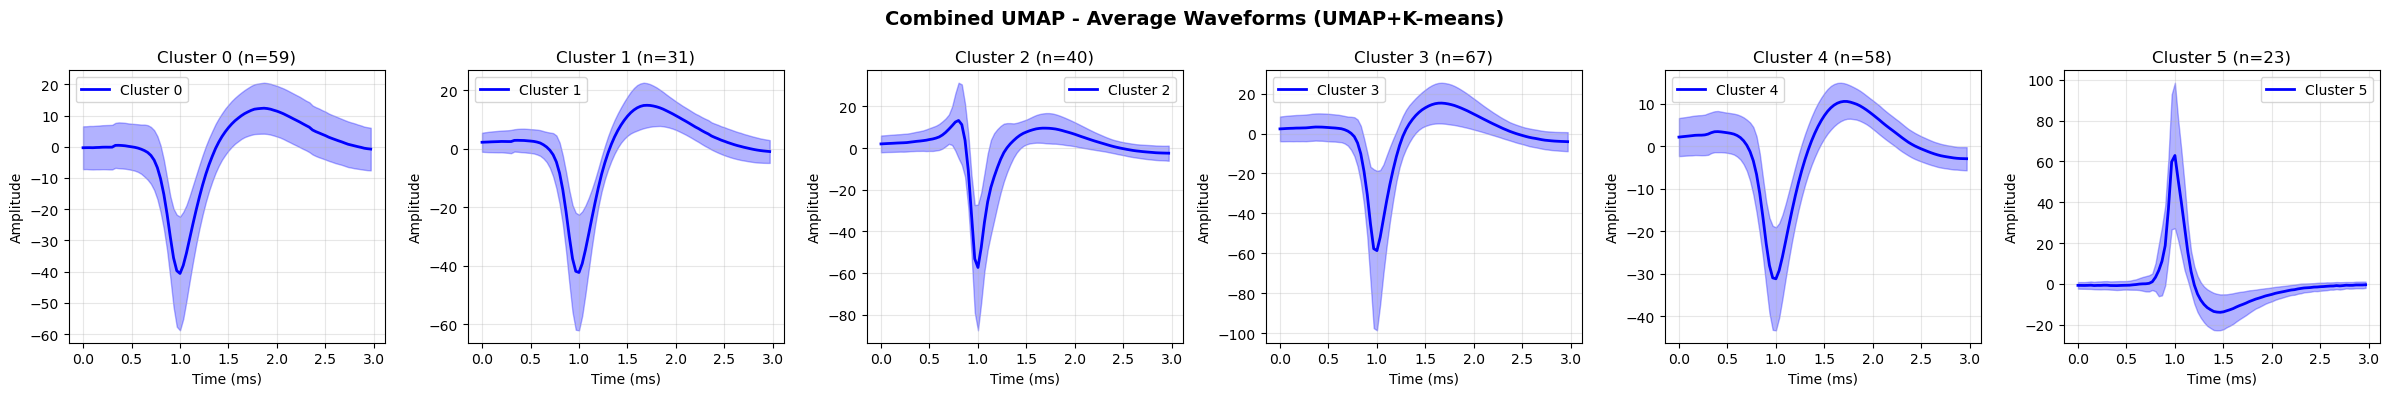

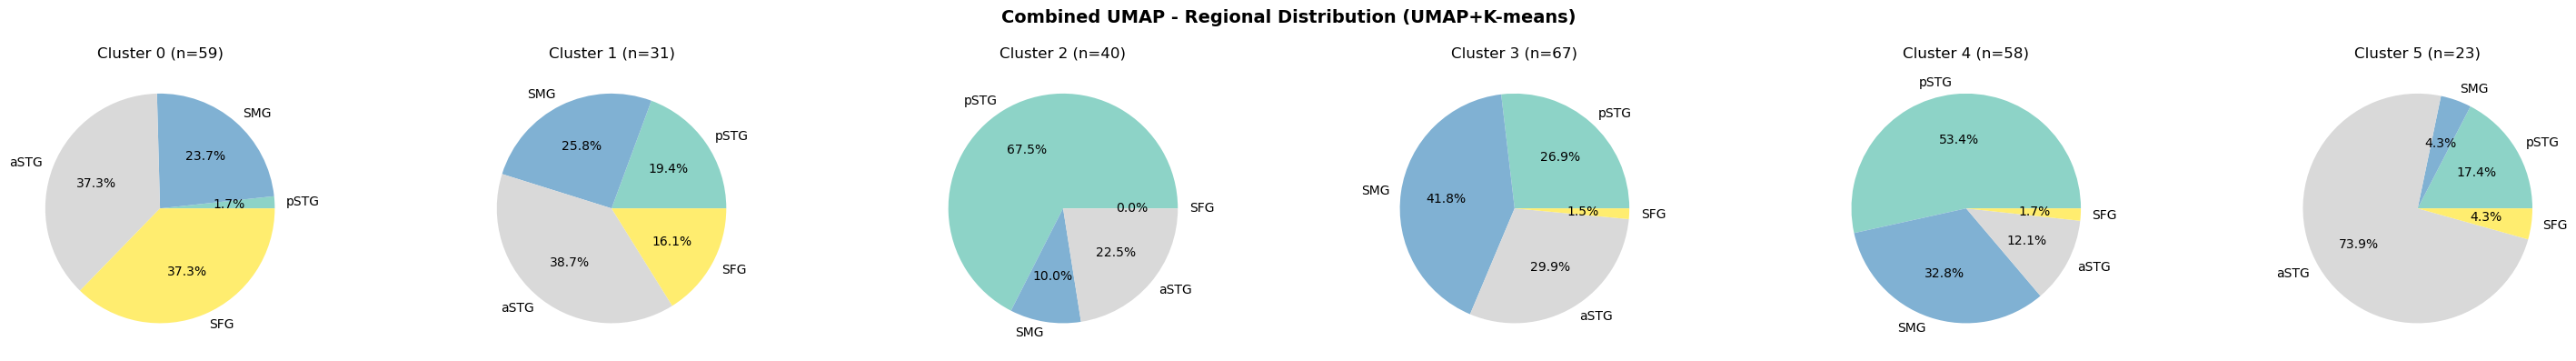

In [9]:
# Visualizaiton cell



#  1. DEFINE COMPREHENSIVE VISUALIZATION FUNCTIONS
print("\n=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

def plot_cluster_waveforms_comprehensive(labels, waveforms_array, title_prefix, n_clusters, method_name):
    """Plot average waveforms for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Average Waveforms ({method_name})', fontsize=14, fontweight='bold')
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_waveforms = waveforms_array[cluster_mask]
        
        if len(cluster_waveforms) > 0:
            # Calculate average waveform
            avg_waveform = np.mean(cluster_waveforms, axis=0)
            std_waveform = np.std(cluster_waveforms, axis=0)
            
            # Plot average waveform with error bars
            x_vals = np.arange(len(avg_waveform)) / 30.0  # Convert to ms
            axes[cluster_id].plot(x_vals, avg_waveform, 'b-', linewidth=2, label=f'Cluster {cluster_id}')
            axes[cluster_id].fill_between(x_vals, 
                                        avg_waveform - std_waveform, 
                                        avg_waveform + std_waveform, 
                                        alpha=0.3, color='blue')
            
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_waveforms)})')
            axes[cluster_id].set_xlabel('Time (ms)')
            axes[cluster_id].set_ylabel('Amplitude')
            axes[cluster_id].grid(True, alpha=0.3)
            axes[cluster_id].legend()
    
    plt.tight_layout()
    plt.savefig("cluster_waveforms.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

def plot_region_pie_charts(labels, metadata, title_prefix, n_clusters, method_name):
    """Plot pie charts showing regional distribution for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Regional Distribution ({method_name})', fontsize=14, fontweight='bold')
    
    # Get unique regions
    all_regions = [meta['region'] for meta in metadata]
    unique_regions = list(set(all_regions))
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_metadata) > 0:
            # Count regions in this cluster
            cluster_regions = [meta['region'] for meta in cluster_metadata]
            region_counts = {region: cluster_regions.count(region) for region in unique_regions}
            
            # Create pie chart
            labels_pie = list(region_counts.keys())
            sizes = list(region_counts.values())
            colors = plt.cm.Set3(np.linspace(0, 1, len(labels_pie)))
            
            axes[cluster_id].pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors)
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_metadata)})')
    
    plt.tight_layout()
    plt.savefig("cluster_region.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

print("Comprehensive visualization functions defined!")



# 2. COMPREHENSIVE VISUALIZATIONS FOR UMAP + K-MEANS CLUSTERING
print("\n=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Convert waveforms_flat to numpy array for visualization
waveforms_array_for_viz = np.array(waveforms_flat)

# Combined UMAP + K-means visualizations
print("\n--- Combined UMAP + K-means Clustering ---")
plot_cluster_waveforms_comprehensive(combined_comp_labels, waveforms_array_for_viz, 
                                    "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
plot_region_pie_charts(combined_comp_labels, comprehensive_metadata, 
                      "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_depth_histograms(combined_comp_labels, comprehensive_metadata, 
#                     "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_subgroup_bar_charts(combined_comp_labels, comprehensive_metadata, 
#                        "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")



=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===
ET-dense regions: ['vPrCG', 'PoCG']
ET-sparse regions: ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']
ET-dense neurons: 0
ET-sparse neurons: 278

=== ET-DENSE REGIONS VISUALIZATION ===
Analyzing 0 neurons from ET-dense regions (vPrCG, PoCG)

--- ET-Dense: Waveform Analysis ---


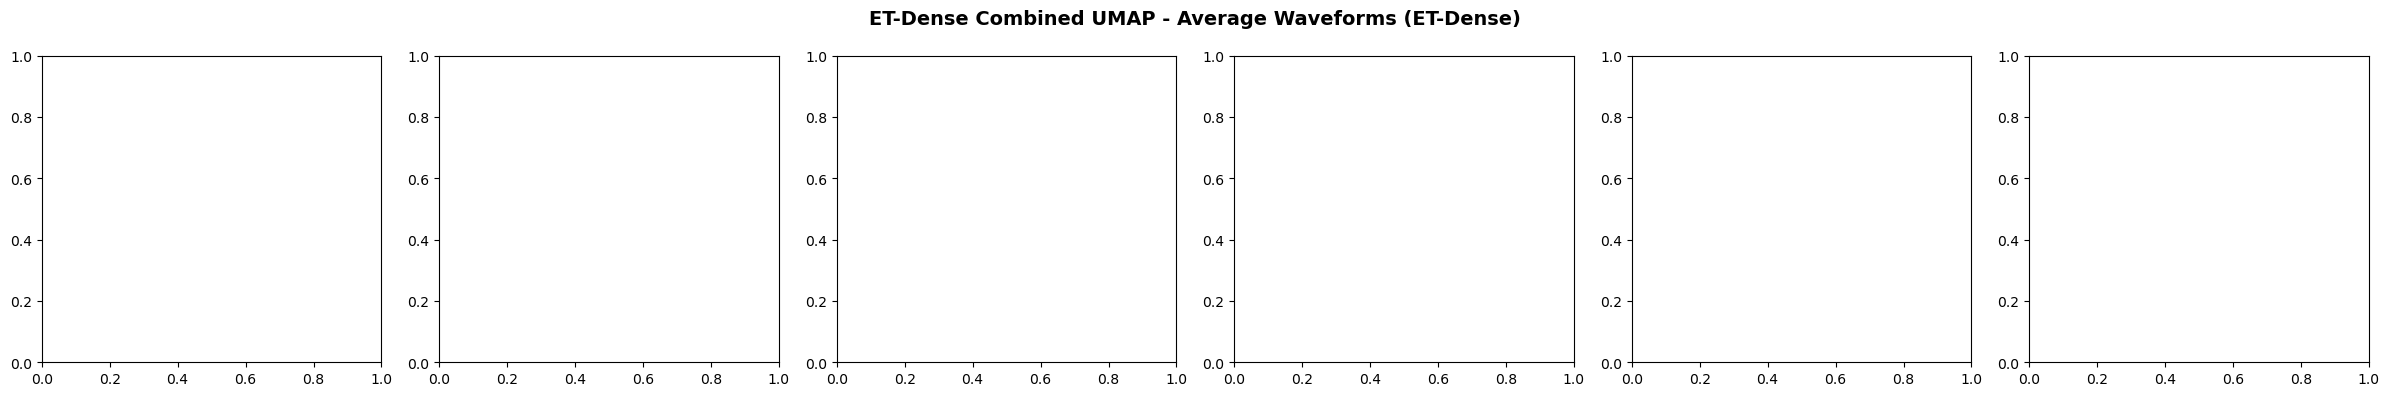


--- ET-Dense: Region Distribution ---


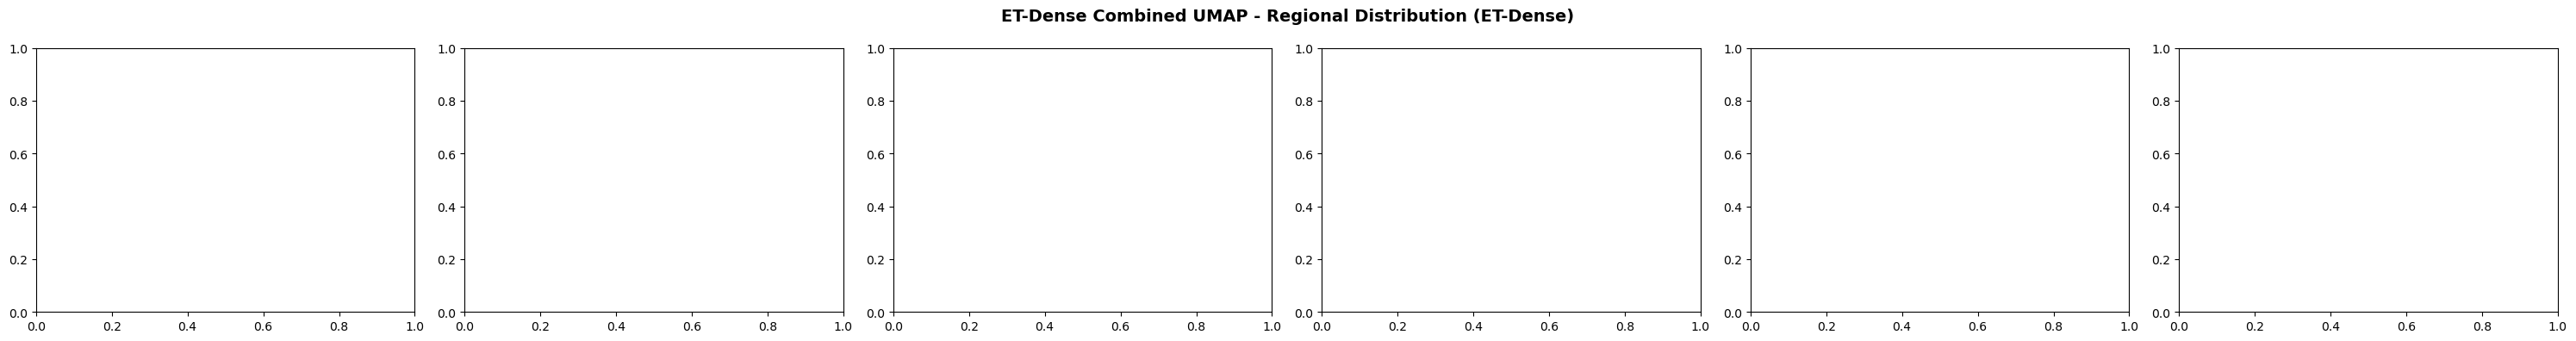


=== ET-SPARSE REGIONS VISUALIZATION ===
Analyzing 278 neurons from ET-sparse regions (all others)

--- ET-Sparse: Waveform Analysis ---


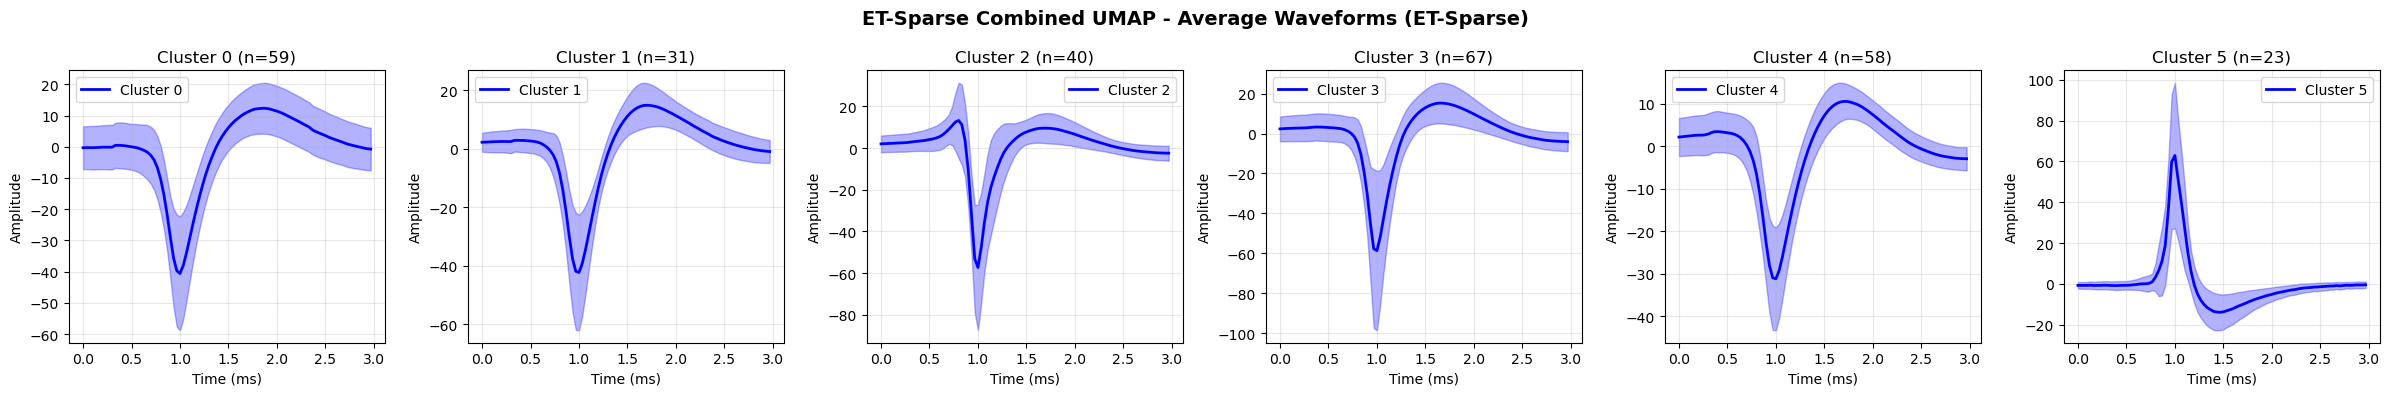


--- ET-Sparse: Region Distribution ---


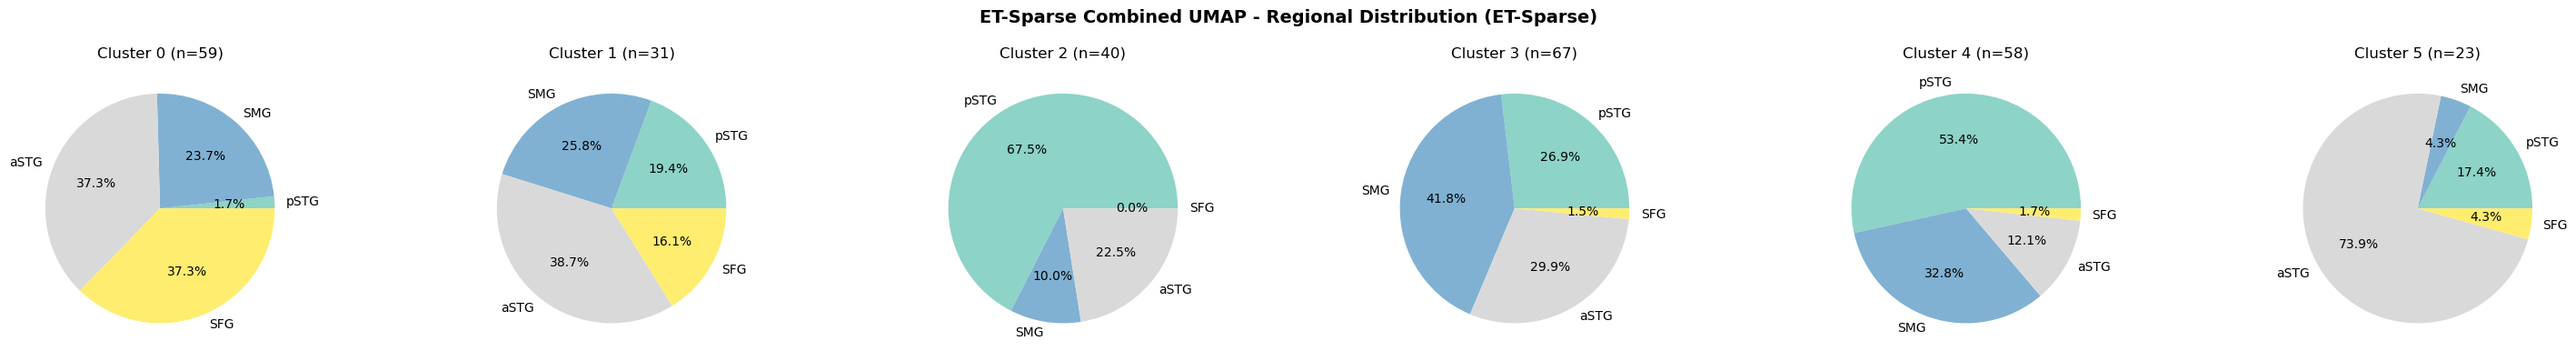

In [10]:
# ET sparse specific visualizations
print("\n=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===")



# 0. Define ET-dense and ET-sparse regions
et_dense_regions = ['vPrCG', 'PoCG']  # Motor and somatosensory cortex
et_sparse_regions = ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']

print(f"ET-dense regions: {et_dense_regions}")
print(f"ET-sparse regions: {et_sparse_regions}")

# Create masks for ET-dense and ET-sparse regions
et_dense_mask = np.array([neuron['region'] in et_dense_regions for neuron in comprehensive_metadata])
et_sparse_mask = np.array([neuron['region'] in et_sparse_regions for neuron in comprehensive_metadata])

print(f"ET-dense neurons: {np.sum(et_dense_mask)}")
print(f"ET-sparse neurons: {np.sum(et_sparse_mask)}")

# Separate the combined clustering data
et_dense_labels = combined_comp_labels[et_dense_mask]
et_sparse_labels = combined_comp_labels[et_sparse_mask]

et_dense_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_dense_mask[i]]
et_sparse_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_sparse_mask[i]]

et_dense_waveforms = waveforms_array_for_viz[et_dense_mask]
et_sparse_waveforms = waveforms_array_for_viz[et_sparse_mask]



# 1. ET-DENSE REGIONS VISUALIZATION
print("\n=== ET-DENSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_dense_labels)} neurons from ET-dense regions (vPrCG, PoCG)")

# 1. Waveform visualizations for ET-dense
print("\n--- ET-Dense: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_dense_labels, et_dense_waveforms, 
                                    "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

# 2. Region pie charts for ET-dense
print("\n--- ET-Dense: Region Distribution ---")
plot_region_pie_charts(et_dense_labels, et_dense_metadata, 
                      "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")



# 2. ET-SPARSE REGIONS VISUALIZATION
print("\n=== ET-SPARSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_sparse_labels)} neurons from ET-sparse regions (all others)")

# 1. Waveform visualizations for ET-sparse
print("\n--- ET-Sparse: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_sparse_labels, et_sparse_waveforms, 
                                    "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

# 2. Region pie charts for ET-sparse
print("\n--- ET-Sparse: Region Distribution ---")
plot_region_pie_charts(et_sparse_labels, et_sparse_metadata, 
                      "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

In [18]:
# PIE CHARTS FOR IDH MUTATION STATUS AND GRADE
# SEPARATE ANALYSES FOR OPERCULAR = 0 AND OPERCULAR = 1
plt.rcParams['svg.fonttype'] = 'none' 

# Filter metadata by opercular status
et_sparse_metadata_op0 = [neuron for neuron in et_sparse_metadata if neuron['opercular'] == 0]
et_sparse_metadata_op1 = [neuron for neuron in et_sparse_metadata if neuron['opercular'] == 1]

# Function to calculate counts and percentages
def calculate_stats(metadata_subset):
    # IDH mutation status counts
    idh_mut_count = sum(1 for neuron in metadata_subset if neuron['pathology'] in ['ast', 'oli'])
    idh_wt_count = sum(1 for neuron in metadata_subset if neuron['pathology'] == 'gbm')
    idh_total = idh_mut_count + idh_wt_count
    
    # Grade counts
    grade_2_3_count = sum(1 for neuron in metadata_subset if neuron['grade'] in [2, 3])
    grade_4_count = sum(1 for neuron in metadata_subset if neuron['grade'] == 4)
    grade_total = grade_2_3_count + grade_4_count
    
    # Calculate percentages
    idh_mut_pct = (idh_mut_count / idh_total * 100) if idh_total > 0 else 0
    idh_wt_pct = (idh_wt_count / idh_total * 100) if idh_total > 0 else 0
    
    grade_2_3_pct = (grade_2_3_count / grade_total * 100) if grade_total > 0 else 0
    grade_4_pct = (grade_4_count / grade_total * 100) if grade_total > 0 else 0
    
    return {
        'idh_mut_count': idh_mut_count,
        'idh_wt_count': idh_wt_count,
        'idh_total': idh_total,
        'idh_mut_pct': idh_mut_pct,
        'idh_wt_pct': idh_wt_pct,
        'grade_2_3_count': grade_2_3_count,
        'grade_4_count': grade_4_count,
        'grade_total': grade_total,
        'grade_2_3_pct': grade_2_3_pct,
        'grade_4_pct': grade_4_pct
    }

# Calculate stats for both groups
stats_op0 = calculate_stats(et_sparse_metadata_op0)
stats_op1 = calculate_stats(et_sparse_metadata_op1)

# Create figure with 4 subplots (2 rows x 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
fig.suptitle('ET-Sparse Regions: IDH Status and Grade Distribution by Opercular Status', 
             fontsize=16, fontweight='bold', y=0.995)

# OPERCULAR = 0: IDH Mutation Status
ax1 = axes[0, 0]
idh_labels = ['IDH mut', 'IDH wt']
idh_counts_op0 = [stats_op0['idh_mut_count'], stats_op0['idh_wt_count']]
idh_colors = ['#2ca02c', '#ff7f0e']  # Green for mut, Orange for wt

wedges, texts, autotexts = ax1.pie(idh_counts_op0, labels=idh_labels, colors=idh_colors, autopct='', 
                                   startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})

for i, (wedge, count, pct) in enumerate(zip(wedges, idh_counts_op0, 
                                             [stats_op0['idh_mut_pct'], stats_op0['idh_wt_pct']])):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    
    label_text = f'{pct:.1f}%\n(n={count})'
    ax1.text(x * 0.7, y * 0.7, label_text, ha='center', va='center', 
             fontsize=10, fontweight='bold', color='white' if pct > 50 else 'black')

ax1.set_title('Opercular = 0: IDH Mutation Status', fontsize=13, fontweight='bold', pad=15)

# OPERCULAR = 0: Grade Distribution
ax2 = axes[0, 1]
grade_labels = ['Grade 2/3', 'Grade 4']
grade_counts_op0 = [stats_op0['grade_2_3_count'], stats_op0['grade_4_count']]
grade_colors = ['#1f77b4', '#d62728']  # Blue for 2/3, Red for 4

wedges, texts, autotexts = ax2.pie(grade_counts_op0, labels=grade_labels, colors=grade_colors, autopct='', 
                                    startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})

for i, (wedge, count, pct) in enumerate(zip(wedges, grade_counts_op0, 
                                             [stats_op0['grade_2_3_pct'], stats_op0['grade_4_pct']])):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    
    label_text = f'{pct:.1f}%\n(n={count})'
    ax2.text(x * 0.7, y * 0.7, label_text, ha='center', va='center', 
             fontsize=10, fontweight='bold', color='white' if pct > 50 else 'black')

ax2.set_title('Opercular = 0: Grade Distribution', fontsize=13, fontweight='bold', pad=15)

# OPERCULAR = 1: IDH Mutation Status
ax3 = axes[1, 0]
idh_counts_op1 = [stats_op1['idh_mut_count'], stats_op1['idh_wt_count']]

wedges, texts, autotexts = ax3.pie(idh_counts_op1, labels=idh_labels, colors=idh_colors, autopct='', 
                                   startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})

for i, (wedge, count, pct) in enumerate(zip(wedges, idh_counts_op1, 
                                             [stats_op1['idh_mut_pct'], stats_op1['idh_wt_pct']])):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    
    label_text = f'{pct:.1f}%\n(n={count})'
    ax3.text(x * 0.7, y * 0.7, label_text, ha='center', va='center', 
             fontsize=10, fontweight='bold', color='white' if pct > 50 else 'black')

ax3.set_title('Opercular = 1: IDH Mutation Status', fontsize=13, fontweight='bold', pad=15)

# OPERCULAR = 1: Grade Distribution
ax4 = axes[1, 1]
grade_counts_op1 = [stats_op1['grade_2_3_count'], stats_op1['grade_4_count']]

wedges, texts, autotexts = ax4.pie(grade_counts_op1, labels=grade_labels, colors=grade_colors, autopct='', 
                                    startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})

for i, (wedge, count, pct) in enumerate(zip(wedges, grade_counts_op1, 
                                             [stats_op1['grade_2_3_pct'], stats_op1['grade_4_pct']])):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    
    label_text = f'{pct:.1f}%\n(n={count})'
    ax4.text(x * 0.7, y * 0.7, label_text, ha='center', va='center', 
             fontsize=10, fontweight='bold', color='white' if pct > 50 else 'black')

ax4.set_title('Opercular = 1: Grade Distribution', fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("idh_grade_pie_charts_by_opercular.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=== OPERCULAR = 0 ===")
print("IDH Mutation Status:")
print(f"  IDH mut: {stats_op0['idh_mut_count']} ({stats_op0['idh_mut_pct']:.1f}%)")
print(f"  IDH wt: {stats_op0['idh_wt_count']} ({stats_op0['idh_wt_pct']:.1f}%)")
print(f"  Total: {stats_op0['idh_total']}")
print("\nGrade Distribution:")
print(f"  Grade 2/3: {stats_op0['grade_2_3_count']} ({stats_op0['grade_2_3_pct']:.1f}%)")
print(f"  Grade 4: {stats_op0['grade_4_count']} ({stats_op0['grade_4_pct']:.1f}%)")
print(f"  Total: {stats_op0['grade_total']}")

print("\n=== OPERCULAR = 1 ===")
print("IDH Mutation Status:")
print(f"  IDH mut: {stats_op1['idh_mut_count']} ({stats_op1['idh_mut_pct']:.1f}%)")
print(f"  IDH wt: {stats_op1['idh_wt_count']} ({stats_op1['idh_wt_pct']:.1f}%)")
print(f"  Total: {stats_op1['idh_total']}")
print("\nGrade Distribution:")
print(f"  Grade 2/3: {stats_op1['grade_2_3_count']} ({stats_op1['grade_2_3_pct']:.1f}%)")
print(f"  Grade 4: {stats_op1['grade_4_count']} ({stats_op1['grade_4_pct']:.1f}%)")
print(f"  Total: {stats_op1['grade_total']}")

ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1400x1400 with 4 Axes>

ET-Sparse regions analysis by opercular status = 0:
ET-Sparse oli+ast opercular=0 proportions: [0.29347826 0.29347826 0.41304348]
ET-Sparse gbm opercular=0 proportions: [0.56097561 0.14634146 0.29268293]
ET-Sparse grade 2+3 opercular=0 proportions: [0.51428571 0.17142857 0.31428571]
ET-Sparse grade 4 opercular=0 proportions: [0.43333333 0.21666667 0.35      ]

=== STATISTICAL TESTS ===
Pathology comparison (oli+ast vs gbm):
  Overall Chi-square = 16.0939, p-value = 0.0003
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 14.176, p = 0.0002 ***
      oli+ast prop = 0.293, gbm prop = 0.561
    Cluster 1: χ² = 6.025, p = 0.0141 *
      oli+ast prop = 0.293, gbm prop = 0.146
    Cluster 2: χ² = 2.866, p = 0.0905 ns
      oli+ast prop = 0.413, gbm prop = 0.293

Grade comparison (2+3 vs 4):
  Overall Chi-square = 0.8252, p-value = 0.6619
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 0.484, p = 0.4866 ns
      grade 2+3 prop = 0.514, grade 4 prop = 0.433
    Cluster 1: χ² = 0.141, p

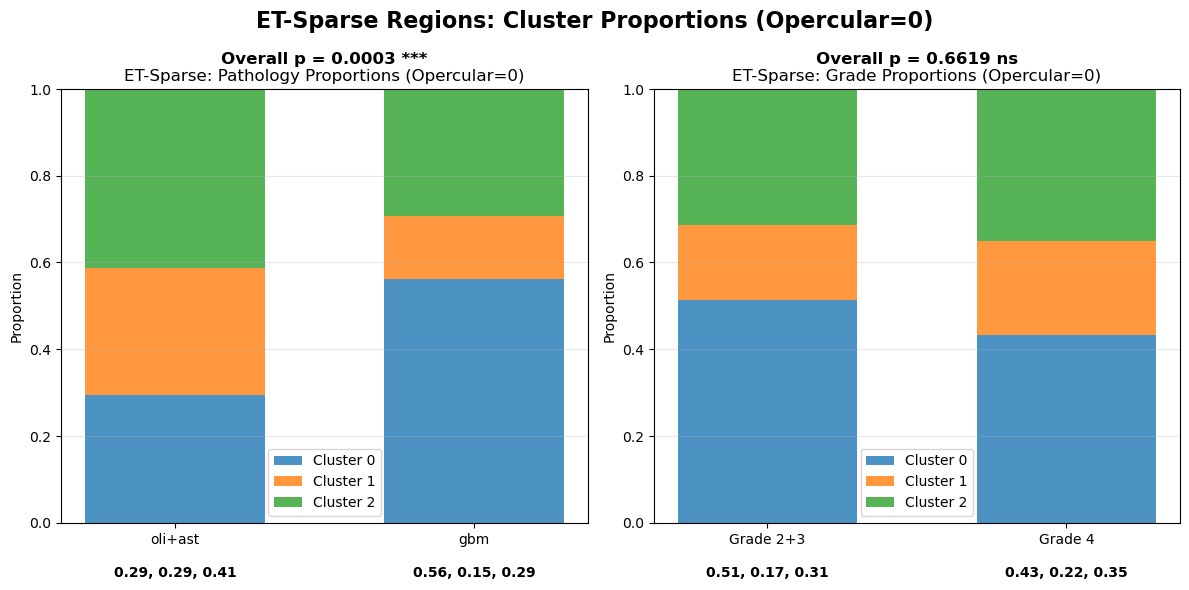


=== DETAILED CLUSTER COMPARISONS ===
Pathology comparison (oli+ast vs gbm) - Cluster proportions:


In [16]:
# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS = 0 ONLY
# WITH STATISTICAL COMPARISONS AND POST-HOC PAIRWISE TESTS
plt.rcParams['svg.fonttype'] = 'none' 

# Function to calculate proportions for opercular subgroups
def calculate_proportions_opercular(labels, metadata, group_variable, group_values, opercular_value):
    """Calculate proportion of each cluster within a specific group and opercular status"""
    if isinstance(group_values, str):
        group_values = [group_values]
    
    group_mask = np.array([neuron[group_variable] in group_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    combined_mask = group_mask & opercular_mask
    
    group_labels = labels[combined_mask]
    
    if len(group_labels) == 0:
        return np.zeros(3)  # Return zeros if no data
    
    cluster_counts = np.bincount(group_labels, minlength=3)
    proportions = cluster_counts / np.sum(cluster_counts)
    return proportions

# Function to perform chi-square test for cluster proportions
def chi_square_test_clusters(labels, metadata, group_variable, group1_values, group2_values, opercular_value):
    """Perform chi-square test comparing cluster distributions between two groups"""
    from scipy.stats import chi2_contingency
    
    # Get masks for both groups
    group1_mask = np.array([neuron[group_variable] in group1_values for neuron in metadata])
    group2_mask = np.array([neuron[group_variable] in group2_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    
    combined_mask1 = group1_mask & opercular_mask
    combined_mask2 = group2_mask & opercular_mask
    
    group1_labels = labels[combined_mask1]
    group2_labels = labels[combined_mask2]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None, None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    contingency_table = np.array([group1_counts, group2_counts])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    return chi2, p_value

# Function to perform post-hoc pairwise comparisons for individual clusters
def posthoc_cluster_comparisons(labels, metadata, group_variable, group1_values, group2_values, opercular_value):
    """Perform post-hoc comparisons for each individual cluster"""
    from scipy.stats import chi2_contingency
    
    # Get masks for both groups
    group1_mask = np.array([neuron[group_variable] in group1_values for neuron in metadata])
    group2_mask = np.array([neuron[group_variable] in group2_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    
    combined_mask1 = group1_mask & opercular_mask
    combined_mask2 = group2_mask & opercular_mask
    
    group1_labels = labels[combined_mask1]
    group2_labels = labels[combined_mask2]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    results = []
    
    # Test each cluster individually (cluster vs all others)
    for cluster_id in range(3):
        # Create 2x2 contingency table: cluster vs all others
        cluster1_count = group1_counts[cluster_id]
        other1_count = np.sum(group1_counts) - cluster1_count
        
        cluster2_count = group2_counts[cluster_id]
        other2_count = np.sum(group2_counts) - cluster2_count
        
        contingency_2x2 = np.array([[cluster1_count, other1_count],
                                   [cluster2_count, other2_count]])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_2x2)
        
        results.append({
            'cluster': cluster_id,
            'chi2': chi2,
            'p_value': p_value,
            'group1_prop': cluster1_count / np.sum(group1_counts),
            'group2_prop': cluster2_count / np.sum(group2_counts)
        })
    
    return results

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS = 0 ONLY
print("ET-Sparse regions analysis by opercular status = 0:")

# ET-Sparse: Pathology proportions by opercular status = 0
et_sparse_oli_ast_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], 0)
et_sparse_gbm_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['gbm'], 0)

# ET-Sparse: Grade proportions by opercular status = 0
et_sparse_grade2_3_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], 0)
et_sparse_grade4_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [4], 0)

print(f"ET-Sparse oli+ast opercular=0 proportions: {et_sparse_oli_ast_op0_props}")
print(f"ET-Sparse gbm opercular=0 proportions: {et_sparse_gbm_op0_props}")
print(f"ET-Sparse grade 2+3 opercular=0 proportions: {et_sparse_grade2_3_op0_props}")
print(f"ET-Sparse grade 4 opercular=0 proportions: {et_sparse_grade4_op0_props}")

# Perform statistical tests
print("\n=== STATISTICAL TESTS ===")

# Pathology comparison (oli+ast vs gbm)
chi2_path, p_path = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], ['gbm'], 0)
print(f"Pathology comparison (oli+ast vs gbm):")
print(f"  Overall Chi-square = {chi2_path:.4f}, p-value = {p_path:.4f}")

# Post-hoc pairwise comparisons for pathology
path_posthoc = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], ['gbm'], 0)
if path_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in path_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      oli+ast prop = {result['group1_prop']:.3f}, gbm prop = {result['group2_prop']:.3f}")

# Grade comparison (2+3 vs 4)
chi2_grade, p_grade = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], [4], 0)
print(f"\nGrade comparison (2+3 vs 4):")
print(f"  Overall Chi-square = {chi2_grade:.4f}, p-value = {p_grade:.4f}")

# Post-hoc pairwise comparisons for grade
grade_posthoc = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], [4], 0)
if grade_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in grade_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      grade 2+3 prop = {result['group1_prop']:.3f}, grade 4 prop = {result['group2_prop']:.3f}")

# Create plots for ET-Sparse regions by opercular status = 0 only
fig_sparse, axes_sparse = plt.subplots(1, 2, figsize=(12, 6))
fig_sparse.suptitle('ET-Sparse Regions: Cluster Proportions (Opercular=0)', fontsize=16, fontweight='bold')

# PLOT 1: ET-Sparse Pathology Proportions - Opercular=0
ax1 = axes_sparse[0]
groups = ['oli+ast', 'gbm']
et_sparse_path_op0_data = [et_sparse_oli_ast_op0_props, et_sparse_gbm_op0_props]

# Create stacked bars
x_pos = np.arange(len(groups))
width = 0.6

bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_path_op0_data).T, cluster_colors)):
    ax1.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Sparse: Pathology Proportions (Opercular=0)')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_path_op0_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax1.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_path is not None:
    significance = "***" if p_path < 0.001 else "**" if p_path < 0.01 else "*" if p_path < 0.05 else "ns"
    ax1.text(0.5, 1.05, f"Overall p = {p_path:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax1.transAxes)

# PLOT 2: ET-Sparse Grade Proportions - Opercular=0
ax2 = axes_sparse[1]
groups = ['Grade 2+3', 'Grade 4']
et_sparse_grade_op0_data = [et_sparse_grade2_3_op0_props, et_sparse_grade4_op0_props]

# Create stacked bars
bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_grade_op0_data).T, cluster_colors)):
    ax2.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Sparse: Grade Proportions (Opercular=0)')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(groups)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_grade_op0_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax2.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_grade is not None:
    significance = "***" if p_grade < 0.001 else "**" if p_grade < 0.01 else "*" if p_grade < 0.05 else "ns"
    ax2.text(0.5, 1.05, f"Overall p = {p_grade:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("groupproprotions_sparse.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed cluster-by-cluster comparisons
print("\n=== DETAILED CLUSTER COMPARISONS ===")

# Pathology comparison - cluster by cluster
print("Pathology comparison (oli+ast vs gbm) - Cluster proportions:")
for i in range(3):
    oli_ast_prop = et_sparse_oli_ast_op0_props[i]
    gbm_prop = et_sparse_gbm_op0_props[i]
    diff = gbm_prop - oli_ast_prop


ET-Sparse regions analysis by opercular status = 1:
ET-Sparse oli+ast opercular=1 proportions: [0.5902439  0.12682927 0.28292683]
ET-Sparse gbm opercular=1 proportions: [0.63636364 0.09090909 0.27272727]
ET-Sparse grade 2+3 opercular=1 proportions: [0.59701493 0.12935323 0.27363184]
ET-Sparse grade 4 opercular=1 proportions: [0.57692308 0.07692308 0.34615385]

=== STATISTICAL TESTS ===
Pathology comparison (oli+ast vs gbm):
  Overall Chi-square = 0.2862, p-value = 0.8667
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 0.036, p = 0.8491 ns
      oli+ast prop = 0.590, gbm prop = 0.636
    Cluster 1: χ² = 0.021, p = 0.8841 ns
      oli+ast prop = 0.127, gbm prop = 0.091
    Cluster 2: χ² = 0.000, p = 1.0000 ns
      oli+ast prop = 0.283, gbm prop = 0.273

Grade comparison (2+3 vs 4):
  Overall Chi-square = 0.9582, p-value = 0.6194
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 0.000, p = 1.0000 ns
      grade 2+3 prop = 0.597, grade 4 prop = 0.577
    Cluster 1: χ² = 0.201, p =

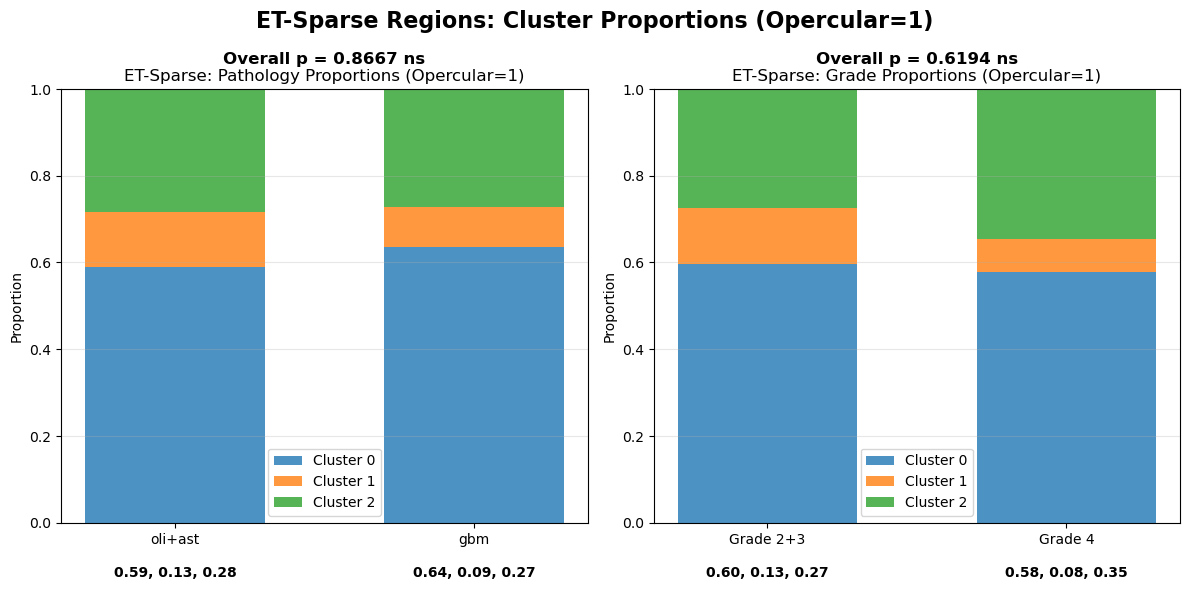


=== DETAILED CLUSTER COMPARISONS ===
Pathology comparison (oli+ast vs gbm) - Cluster proportions:
  Cluster 0: oli+ast = 0.590, gbm = 0.636, diff = 0.046
  Cluster 1: oli+ast = 0.127, gbm = 0.091, diff = -0.036
  Cluster 2: oli+ast = 0.283, gbm = 0.273, diff = -0.010

Grade comparison (2+3 vs 4) - Cluster proportions:
  Cluster 0: grade 2+3 = 0.597, grade 4 = 0.577, diff = -0.020
  Cluster 1: grade 2+3 = 0.129, grade 4 = 0.077, diff = -0.052
  Cluster 2: grade 2+3 = 0.274, grade 4 = 0.346, diff = 0.073


In [17]:
# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS = 1 ONLY
# WITH STATISTICAL COMPARISONS AND POST-HOC PAIRWISE TESTS
plt.rcParams['svg.fonttype'] = 'none' 

# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS = 1 ONLY
print("ET-Sparse regions analysis by opercular status = 1:")

# ET-Sparse: Pathology proportions by opercular status = 1
et_sparse_oli_ast_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], 1)
et_sparse_gbm_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['gbm'], 1)

# ET-Sparse: Grade proportions by opercular status = 1
et_sparse_grade2_3_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], 1)
et_sparse_grade4_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [4], 1)

print(f"ET-Sparse oli+ast opercular=1 proportions: {et_sparse_oli_ast_op1_props}")
print(f"ET-Sparse gbm opercular=1 proportions: {et_sparse_gbm_op1_props}")
print(f"ET-Sparse grade 2+3 opercular=1 proportions: {et_sparse_grade2_3_op1_props}")
print(f"ET-Sparse grade 4 opercular=1 proportions: {et_sparse_grade4_op1_props}")

# Perform statistical tests
print("\n=== STATISTICAL TESTS ===")

# Pathology comparison (oli+ast vs gbm)
chi2_path_op1, p_path_op1 = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], ['gbm'], 1)
print(f"Pathology comparison (oli+ast vs gbm):")
print(f"  Overall Chi-square = {chi2_path_op1:.4f}, p-value = {p_path_op1:.4f}")

# Post-hoc pairwise comparisons for pathology
path_posthoc_op1 = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], ['gbm'], 1)
if path_posthoc_op1:
    print("  Post-hoc pairwise comparisons:")
    for result in path_posthoc_op1:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      oli+ast prop = {result['group1_prop']:.3f}, gbm prop = {result['group2_prop']:.3f}")

# Grade comparison (2+3 vs 4)
chi2_grade_op1, p_grade_op1 = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], [4], 1)
print(f"\nGrade comparison (2+3 vs 4):")
print(f"  Overall Chi-square = {chi2_grade_op1:.4f}, p-value = {p_grade_op1:.4f}")

# Post-hoc pairwise comparisons for grade
grade_posthoc_op1 = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], [4], 1)
if grade_posthoc_op1:
    print("  Post-hoc pairwise comparisons:")
    for result in grade_posthoc_op1:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      grade 2+3 prop = {result['group1_prop']:.3f}, grade 4 prop = {result['group2_prop']:.3f}")

# Create plots for ET-Sparse regions by opercular status = 1 only
fig_sparse_op1, axes_sparse_op1 = plt.subplots(1, 2, figsize=(12, 6))
fig_sparse_op1.suptitle('ET-Sparse Regions: Cluster Proportions (Opercular=1)', fontsize=16, fontweight='bold')

# PLOT 1: ET-Sparse Pathology Proportions - Opercular=1
ax1 = axes_sparse_op1[0]
groups = ['oli+ast', 'gbm']
et_sparse_path_op1_data = [et_sparse_oli_ast_op1_props, et_sparse_gbm_op1_props]

# Create stacked bars
x_pos = np.arange(len(groups))
width = 0.6

bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_path_op1_data).T, cluster_colors)):
    ax1.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Sparse: Pathology Proportions (Opercular=1)')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_path_op1_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax1.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_path_op1 is not None:
    significance = "***" if p_path_op1 < 0.001 else "**" if p_path_op1 < 0.01 else "*" if p_path_op1 < 0.05 else "ns"
    ax1.text(0.5, 1.05, f"Overall p = {p_path_op1:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax1.transAxes)

# PLOT 2: ET-Sparse Grade Proportions - Opercular=1
ax2 = axes_sparse_op1[1]
groups = ['Grade 2+3', 'Grade 4']
et_sparse_grade_op1_data = [et_sparse_grade2_3_op1_props, et_sparse_grade4_op1_props]

# Create stacked bars
bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_grade_op1_data).T, cluster_colors)):
    ax2.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Sparse: Grade Proportions (Opercular=1)')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(groups)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_grade_op1_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax2.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_grade_op1 is not None:
    significance = "***" if p_grade_op1 < 0.001 else "**" if p_grade_op1 < 0.01 else "*" if p_grade_op1 < 0.05 else "ns"
    ax2.text(0.5, 1.05, f"Overall p = {p_grade_op1:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("groupproprotions_sparse_op1.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed cluster-by-cluster comparisons
print("\n=== DETAILED CLUSTER COMPARISONS ===")

# Pathology comparison - cluster by cluster
print("Pathology comparison (oli+ast vs gbm) - Cluster proportions:")
for i in range(3):
    oli_ast_prop = et_sparse_oli_ast_op1_props[i]
    gbm_prop = et_sparse_gbm_op1_props[i]
    diff = gbm_prop - oli_ast_prop
    print(f"  Cluster {i}: oli+ast = {oli_ast_prop:.3f}, gbm = {gbm_prop:.3f}, diff = {diff:.3f}")

# Grade comparison - cluster by cluster
print("\nGrade comparison (2+3 vs 4) - Cluster proportions:")
for i in range(3):
    grade2_3_prop = et_sparse_grade2_3_op1_props[i]
    grade4_prop = et_sparse_grade4_op1_props[i]
    diff = grade4_prop - grade2_3_prop
    print(f"  Cluster {i}: grade 2+3 = {grade2_3_prop:.3f}, grade 4 = {grade4_prop:.3f}, diff = {diff:.3f}")